In [1]:
#Carrega as bibliotecas que serão usadas
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
import seaborn as sns

# ETAPA 1: estudo das informações gerais.

In [2]:
#Lê o dataframe
df_games = pd.read_csv('games.csv')

In [3]:
#exibe as informações do dataframe
print(df_games.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


In [4]:
#Imprime as 15 primeiras linhas do dataframe
print(df_games.head(15))

                           Name Platform  Year_of_Release         Genre  \
0                    Wii Sports      Wii           2006.0        Sports   
1             Super Mario Bros.      NES           1985.0      Platform   
2                Mario Kart Wii      Wii           2008.0        Racing   
3             Wii Sports Resort      Wii           2009.0        Sports   
4      Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
5                        Tetris       GB           1989.0        Puzzle   
6         New Super Mario Bros.       DS           2006.0      Platform   
7                      Wii Play      Wii           2006.0          Misc   
8     New Super Mario Bros. Wii      Wii           2009.0      Platform   
9                     Duck Hunt      NES           1984.0       Shooter   
10                   Nintendogs       DS           2005.0    Simulation   
11                Mario Kart DS       DS           2005.0        Racing   
12  Pokemon Gold/Pokemon 

# ETAPA 2:  Preparação dos dados.

**Alguns dados vistos no dataframe necessitam de correção, que serão as seguintes:**

In [5]:
#Deixa o nome das colunas em letra minúscula
df_games.columns = df_games.columns.str.lower()

In [6]:
#Converte 'user_score' de string (object) para número de ponto flutuante (float) além de substituir os valores 'tbd' por NaN
df_games['user_score'] = df_games['user_score'].replace('tbd', np.nan).astype(float)

#Converte 'year_of_release' de número de ponto flutuante (float) para um número inteiro (int64)
df_games['year_of_release'] = pd.to_numeric(df_games['year_of_release'], errors = 'coerce').astype('Int64')

print(df_games.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB
None


**Para melhor facilidade na digitação dos nomes das colunas, todos os nomes delas foram convertidos para que todas as letras sejam minúsculas.**

**A coluna user_score foi convertida de string (object) para número de ponto flutuante (float64). Isso foi feito pois a coluna continha valores de texto como 'tbd', que precisaram ser convertidos para valores nulos (NaN) antes que o tipo de dado pudesse ser alterado para numérico. Isso permite a realização de cálculos e análises estatísticas na coluna.**

**A coluna year_of_release foi convertida de ponto flutuante (float64) para número inteiro com suporte a valores nulos (Int64), já que anos são valores inteiros. Essa abordagem preserva os dados faltantes (NaN).**

In [7]:
#Soma a quantidade de valores vazios em cada uma das colunas.
print(df_games.isnull().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


**Observando a quantidade total de valores ausentes em cada uma das colunas, aqui estão as melhores estratégias para lidar com eles:**

**As colunas 'name' e 'genre' possuem apenas 2 valores ausentes, ou seja, o ideal seria mante-las como estão, já que essas são no máximo apenas 4 linhas de um total de mais de 16 mil, o impacto de sua presença seria mínimo. Para melhor interpretação, os valores vazios serão substituidos por 'ausente'.**

**A coluna 'year_of_release' possui 269 valores ausentes, um valor baixo. Como o ano de lançamento é uma informação bem específica que no geral não é de extrema importância para a análise que será feita, além de não ser uma quantidade significativa se comparado ao total de linhas, o melhor seria deixar os valores vazios como estão.**

**As colunas 'critic_score' e 'user_score' possuem uma alta quantidade de valores ausentes, mais da metade das linhas do dataframe possuem o valor da avaliação do usuário ou da mídia vazia. Por mais que seja um grande número de valores vazios, tentar subistituir esses valores vazios pela média ou mediana poderia afetar artificialmente as notas gerais dos jogos e a real distribuição dos dados. Um valor vazio para essas duas colunas pode muito bem indicar que o jogo ainda não foi avaliado, e preenche-las com algum outro valor seria mera especulação.**

**Por fim, a coluna 'rating' possui aproximadamente 6800 valores ausentes. A melhor alternativa seria manter esses valores como NaN. A presença ou não da classificação indicativa de um jogo é uma categoria de informação e a remoção de todas as linhas com classificações ausentes resultaria grande quantidade de dados sendo perdidos. Sendo assim, manter as linhas ausentes seria a mehlor escolha para preservar os dados.**

**Os valores ausentes em 'name', 'genre' e 'year_of_release' podem estar vazios por algum erro ao inserir essas informações no dataframe, considerando que a quantidade de valores ausentes é mínima se compados a quantidade de valores ausentes de outras colunas.**

**Os valores em 'user_score', 'critic_score' e em 'rating' provavelemente estão vazios pelo fato de ditos jogos não terem sido avaliados ainda.**

**A abreviação 'tbt' (to be dated) foi removida e substituída por NaN anteriormente no código quando converti o valor da análise de usuário de object para float caso os valores da coluna sejam necessários para uma análise numérica. Como explicado anteriormente, os valores vazios em 'user_score' indicam que os usuários não analisaram o jogo ainda.**

In [8]:
#CORREÇÃO DOS VALORES AUSENTES:

#Substitui os valores vazios em 'game' e 'genre' por 'ausente'
df_games['name'].fillna('ausente', inplace = True)
df_games['genre'].fillna('ausente', inplace = True)

print(df_games.isnull().sum())

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


C:\Users\andre\AppData\Local\Temp\ipykernel_10672\193688225.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_games['name'].fillna('ausente', inplace = True)
C:\Users\andre\AppData\Local\Temp\ipykernel_10672\193688225.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [9]:
#Cria a coluno 'total_sales' que soma o valor de vendas totais em cada uma das regiões
df_games['total_sales'] = df_games['na_sales'] + df_games['eu_sales'] + df_games['jp_sales']

print(df_games.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
1      3.58      6.81         0.77           NaN         NaN    NaN   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         2.95          80.0         8.0      E   
4      8.89     10.22         1.00           NaN         NaN    NaN   

   total_sales  
0        74.09  
1        39.47  
2        32.23  
3        29.82  
4

# ETAPA 3: Análise dos dados.

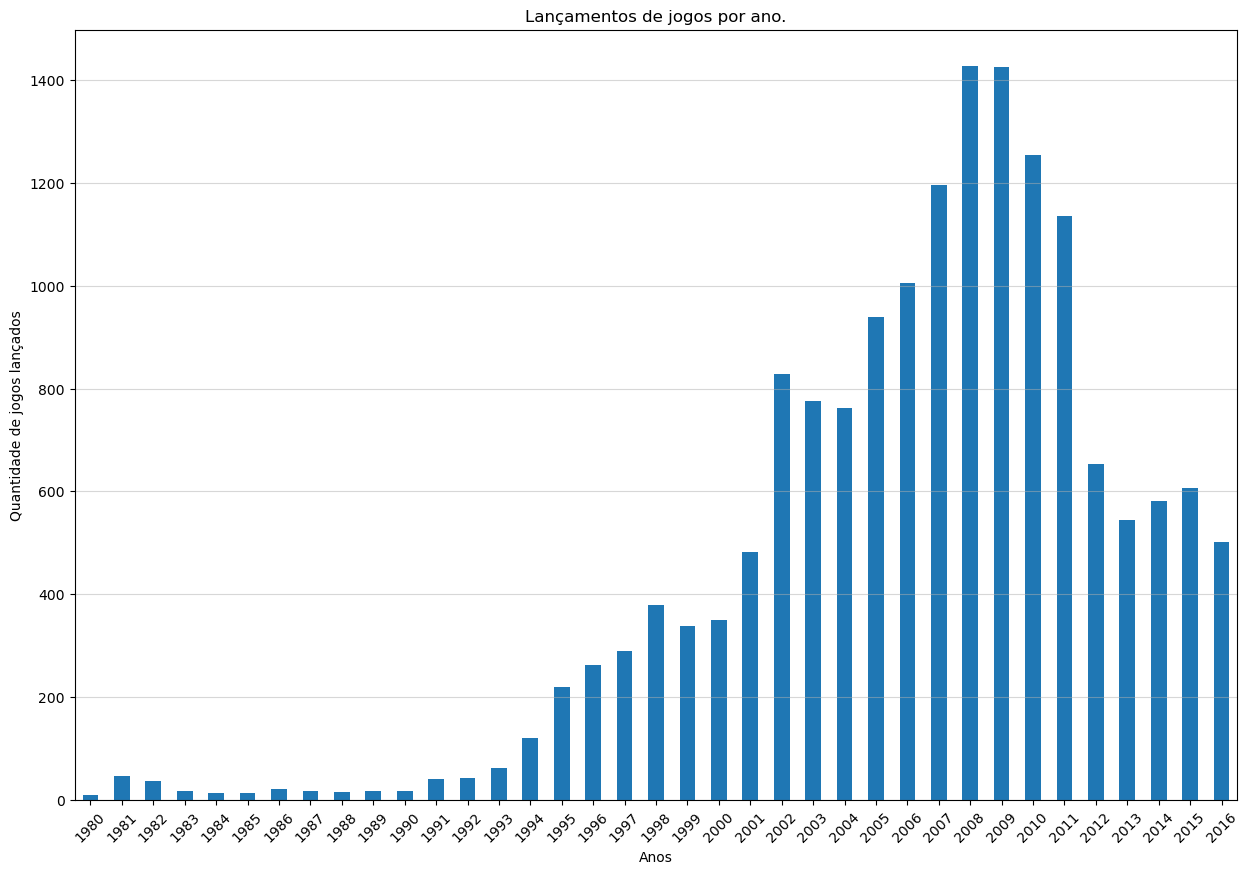

In [10]:
#Cria um gráfico de barras que mostra quantos jogos foram lançados em cada ano
games_per_year = df_games['year_of_release'].value_counts().sort_index()

games_per_year.plot(figsize = (15, 10), kind = 'bar')
plt.title('Lançamentos de jogos por ano.')
plt.xlabel('Anos')
plt.xticks(rotation = 45)
plt.ylabel('Quantidade de jogos lançados')
plt.grid(axis = 'y', alpha = 0.5)
plt.show()

**Analizando a quantidade de jogos lançados em cada ano, pode-se notar uma significância distinta em três períodos diferentes, sendo eles os anos 80 até o início dos anos 90, o final dos anos 90 até o início dos anos 2010, e os anos 2010 em diante.**

**Dados de jogos lançados nos anos 80 até o início dos anos 90 tem um número muito baixo, refletindo o tamanho ainda pequeno da indústria de videogames naquela época e a limitada distribuição de títulos. Por causa disso, dados dos anos de 1980 a 1990 não serão utilizados.**

**Dados de jogos lançados no final dos anos 90 até o início dos anos 2010 mostra um crescimento explosivo, com o número de lançamentos atingindo o ápice em 2008. Isso coincide com o auge da sétima geração de consoles (Wii, Xbox 360, PlayStation 3) e o crescimento massivo do mercado de jogos. A densidade de dados para esses anos sugere que eles são uma amostra muito mais robusta e representativa da produção da indústria de jogos. Sendo ideais para se usarem como base para as análises futuras.**

**Dados de jogos lançados de 2010 para frente mostram um declínio acentuado, isso pode ser um reflexo tanto de uma saturação no mercado de jogos ou a consolidação de títulos como de um indício de dados incompletos. Como o arquivo é de 2016, é de se esperar que os dados dos anos mais recentes estejam parcialmente incompletos, pois leva-se tempo até que todas as informações de lançamento e vendas de um jogo sejam compiladas, registradas e liberadasdas publicamente.**

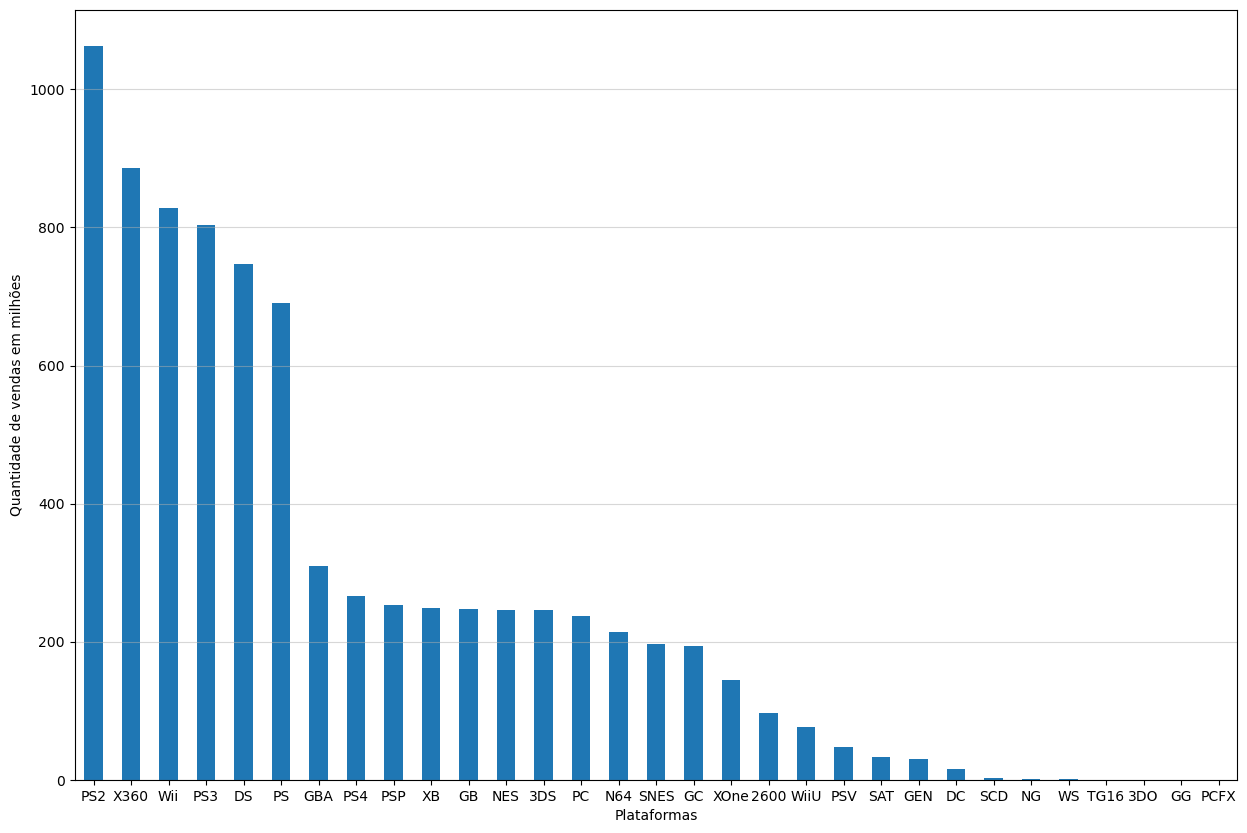

In [11]:
#Cria um gráfico de barras que mostra o número de vendas por cada plataforma
sales_by_platform = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending = False)

sales_by_platform.plot(figsize = (15, 10), kind = 'bar')
plt.xlabel('Plataformas')
plt.xticks(rotation = 0)
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y', alpha = 0.5)
plt.show()

**Analisando o gráfico a seguir, pode-se perceber que as plataformas com mais vendas de todo o dataframe são o Playstation2, o Xbox 360, o Nintendo Wii, o Playstation 3, o Nintendo DS e o Playstation 1. Essas plataformas serão usadas como base para as futuras análises.**

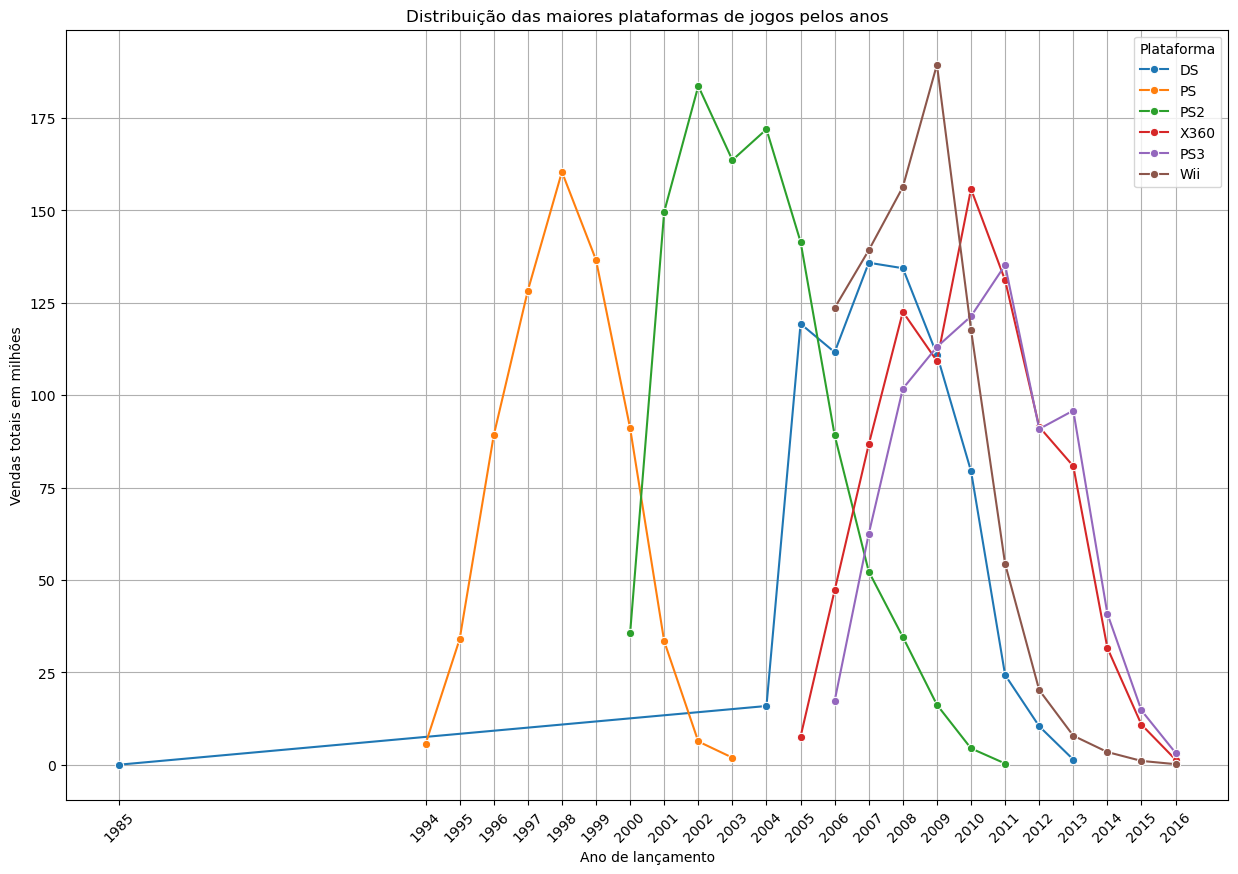

In [12]:
#Filtra df_games pelas 6 maiores plataformas e cria um gráfico de linha que mostra o seus respectivos crescimentos em cada ano
top_6_platforms = df_games.groupby('platform')['total_sales'].sum().nlargest(6).index

df_top_platforms = df_games[df_games['platform'].isin(top_6_platforms)]

yearly_sales = df_top_platforms.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

plt.figure(figsize = (15, 10))
sns.lineplot(data = yearly_sales, x = 'year_of_release', y = 'total_sales', hue = 'platform', marker = 'o')
plt.title('Distribuição das maiores plataformas de jogos pelos anos')
plt.xlabel('Ano de lançamento')
plt.xticks(yearly_sales['year_of_release'].unique(), rotation = 45)
plt.ylabel('Vendas totais em milhões')
plt.grid(True)
plt.legend(title = 'Plataforma')

plt.show()

**Este gráfico de linha visualiza o ciclo de vida de cada plataforma com cada linha representando uma das seis plataformas mais vendidas. É possível ver claramente que cada plataforma tem um pico de vendas que dura apenas alguns anos. Por exemplo, o Wii e o DS tiveram seus picos por volta de 2008-2009. O PS3 e o Xbox 360 tiveram picos um pouco mais tardios, mostrando um ciclo de vida de sucesso mais prolongado.**

**Analizando o gráfico pode-se ver que apesar dessas serem as plataformas com mais vendas de todas elas não são mais populares em 2016, não tendo quase nenhum novo lançamento e, consquentemente, baixos lucros.**

**Também percebe-se que há um jogo de Nintendo DS que consta ter sido lançado em 1985, o que seria impossível pois do DS só foi lançado nos anos 2000, portanto, é de se assumir que o jogo em questão ou possui um erro em seu registro no dataframe, ou se trata de um jogo da época que foi relançado para o DS. De qualquer forma, os anos de 1980 té 1990 não serão inclusos na análise, então este jogo estará fora da análise.**

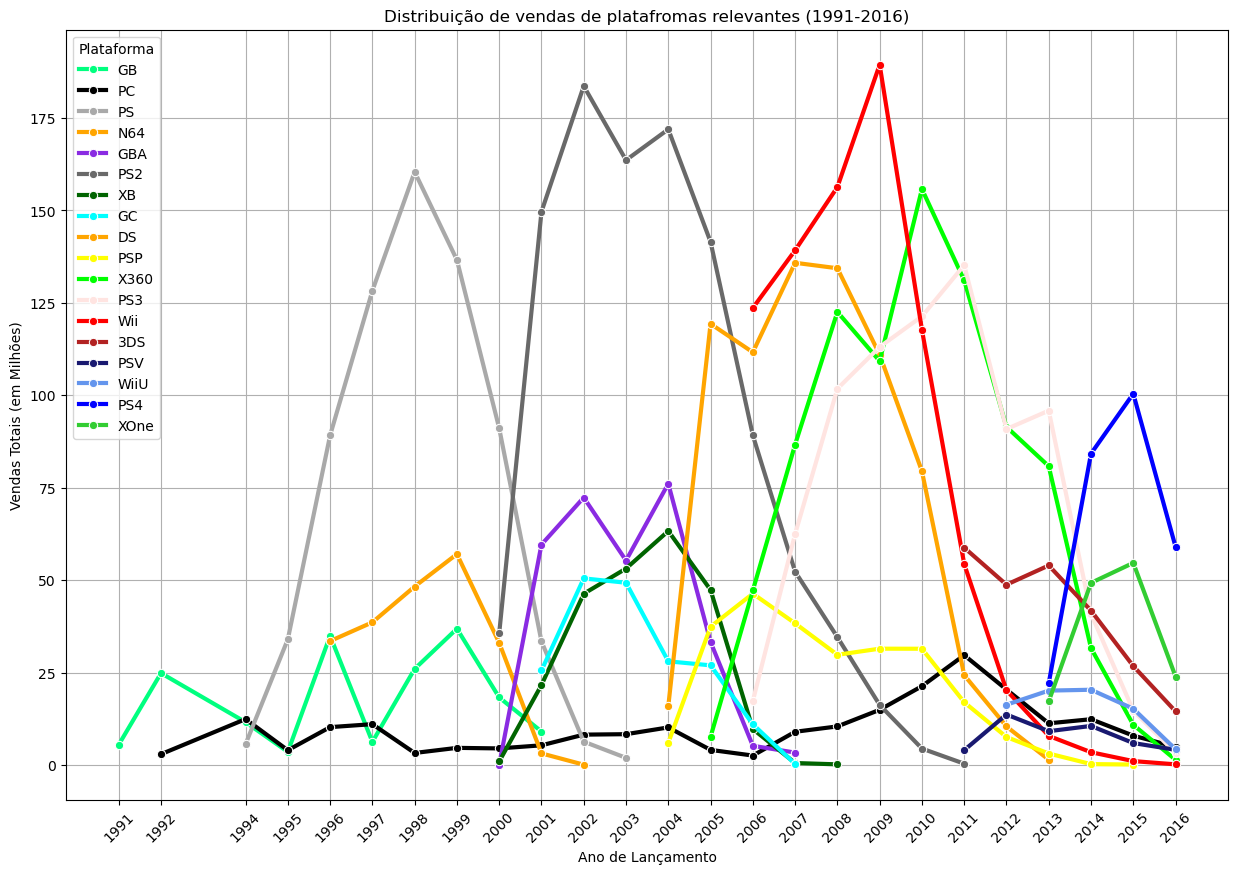

In [13]:

#Filtra plataformas que nunca foram populares ou que não possuem relevância para o mercado de 1991 até 2016
platforms_to_exclude = ['PCFX', 'GG', 'TG16', 'WS', 'NG', 'SDC', 'GEN', 'SAT', '2600', 'NES', '3DO', 'DC', 'SCD', 'SNES']

df_games_filtered = df_games[~df_games['platform'].isin(platforms_to_exclude)]

yearly_sales_all_platforms = df_games_filtered.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

#Cira o dataframe 'yearly_sales_filtered' que filtra apenas jogos que foram lançados nos anos de 1991 em diante
yearly_sales_filtered = yearly_sales_all_platforms[yearly_sales_all_platforms['year_of_release'] > 1990]

#Cria um gráfico de distribuição de linha
plt.figure(figsize=(15, 10))

#Determina cores próprias para cada linha do gráfico para melhor interpretação
custom_palette = {
    'PS': 'darkgray',
    'PS2': 'dimgray',
    'PSP': 'yellow',
    'PS3': 'mistyrose',
    'PSV': 'midnightblue',
    'PS4': 'blue',
    'XB': 'darkgreen',
    'X360': 'lime',
    'XOne': 'limegreen',
    'N64': 'orange',
    'GB': 'springgreen',
    'GC': 'cyan',
    'GBA': 'blueviolet',
    'Wii': 'red',
    'DS': 'orange',
    '3DS': 'firebrick',
    'WiiU': 'cornflowerblue',
    'PC': 'black'}

sns.lineplot(data = yearly_sales_filtered, x = 'year_of_release', y = 'total_sales', hue = 'platform', marker = 'o', linewidth = 3, palette = custom_palette)
plt.title('Distribuição de vendas de platafromas relevantes (1991-2016)')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Vendas Totais (em Milhões)')
plt.xticks(yearly_sales_filtered['year_of_release'].unique(), rotation = 45)
plt.legend(title = 'Plataforma')
plt.grid(True)

plt.show()


**Analizando o gráfico de distribuição agora contendo mais do que as 6 plataformas mais populares, pode-se tirar as seguintes conclusões quanto ao tempo em que plataformas demoram para aparecer e sumir:**

**Uma plataforma costuma ter um tempo de vida útil por volta de 5 a 7 anos (tempo em que o console está no mercado até que um console sucessor dele seja lançado).**

**Um console após o lançamento costuma crescer em vendas por volta de 2 a 4 anos.**

**Pode-se concluir que uma plataforma costuma desaparecer conforme as vendas caem gradualmente após o período de 2 a 4 anos de crescimento. Esta queda se acentua quando um novo console é lançado. A queda de vendas de uma plataforma se coincide com o crescimento de outra.**

**2016 era a era da oitava geração de consoles, sendo eles o PS4, o Xbox One e o WiiU. Sendo esses as opções mais atuais da época no mercado de jogos. Além desses nós temos o PC que desde sempre foi usado para jogos, o 3DS, o Ps Vita, o Wii, o Xbox 360, e o PS3.**

**Analizando as plataformas no ano de 2016, pode-se concluir que os consoles em ascenção são o Playstation 4 o Xbox One e o 3DS enquanto o Xbox 360, o Playstation 3 o Wiiu e o Wii estão em declínio de vendas enquanto o PC, apesar de não ser o mais lucrativo, sempre se manteve em constantes altos e baixos em vendas.**

**Pode-se concluir que as plataformas de jogos que mais valem a pena investir seriam o PS4, Xbox One e 3DS.**

**Para uma melhor análise para o mercado de 2017, os dados dos anos abaixo de 2013 serão desconsiderados.**

In [14]:
#Cria o dataframe 'df_games_recent' que filtra os todos os dados de vendas de jogos que sejam do ano de 2013 para frente

df_games_recent = df_games[df_games['year_of_release'] >= 2013].copy()

print(df_games_recent.head(25))

                                          name platform  year_of_release  \
16                          Grand Theft Auto V      PS3             2013   
23                          Grand Theft Auto V     X360             2013   
31                   Call of Duty: Black Ops 3      PS4             2015   
33                         Pokemon X/Pokemon Y      3DS             2013   
42                          Grand Theft Auto V      PS4             2014   
47   Pokemon Omega Ruby/Pokemon Alpha Sapphire      3DS             2014   
60                        Call of Duty: Ghosts     X360             2013   
69                        Call of Duty: Ghosts      PS3             2013   
72                                   Minecraft     X360             2013   
77                                     FIFA 16      PS4             2015   
87                Star Wars Battlefront (2015)      PS4             2015   
92              Call of Duty: Advanced Warfare      PS4             2014   
94          

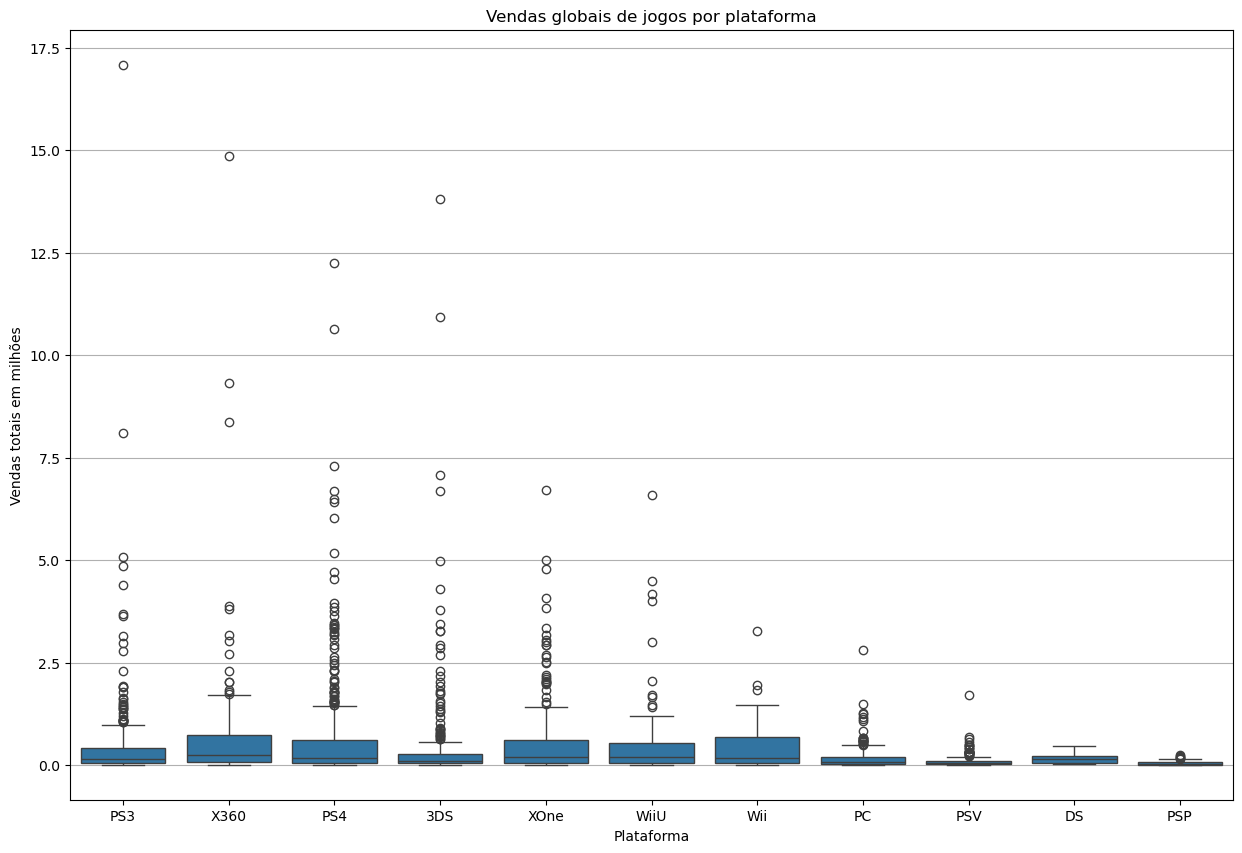

In [15]:
#Cria um diagrama de caixa que examina as vendas globais de jogos por plataforma

plt.figure(figsize = (15, 10))
sns.boxplot(x = 'platform', y = 'total_sales', data = df_games_recent)
plt.title('Vendas globais de jogos por plataforma')
plt.xlabel('Plataforma')
plt.xticks(rotation = 0)
plt.ylabel('Vendas totais em milhões')
plt.grid(axis = 'y')

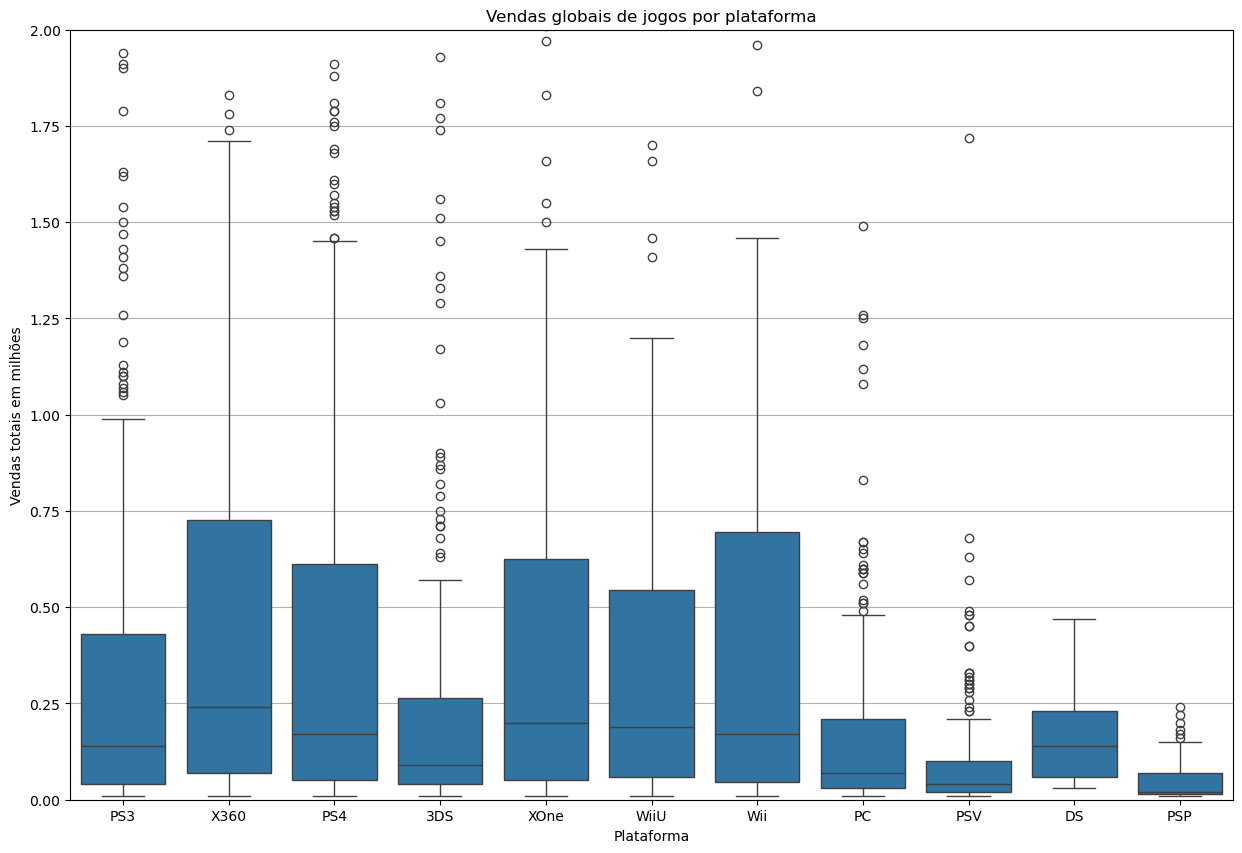

In [16]:
#Cria um segundo diagrama de caixa em escala limitada para melhor visualização

plt.figure(figsize = (15, 10))
sns.boxplot(x = 'platform', y = 'total_sales', data = df_games_recent)
plt.title('Vendas globais de jogos por plataforma')
plt.xlabel('Plataforma')
plt.xticks(rotation = 0)
plt.ylabel('Vendas totais em milhões')
plt.ylim(0, 2)
plt.grid(axis = 'y')

***As diferenças nas vendas são significativas?***

**Sim, as diferenças são extremamente significativas. Como pode-se ver, a maioria das distribuições de vendas são esmagadas no fundo do gráfico. Isso se deve por causa dos outliers (os pontos fora da média), que no caso, seriam jogos que fizeram sucesso fenomenal no mercado comparado com a grande maioria dos outros jogos vendem menos de 1 milhão.**

***E quanto às vendas médias em várias plataformas?***

**A mediana de vendas (linha dentro da caixa) para a maioria das plataformas é muito baixa, perto de zero. Isso indica que a maioria dos jogos, independentemente da plataforma, vende pouco, mas apesar disso, algumas plataformas, como PS2, Wii, X360 e PS3, mostram caixas (e, portanto, medianas) ligeiramente mais altas no segundo gráfico. Isso significa que a distribuição de vendas para essas plataformas é um pouco melhor do que para outras.**

Matriz de correlação para Xbox One: 
              total_sales  user_score  critic_score
total_sales      1.000000   -0.093737      0.410657
user_score      -0.093737    1.000000      0.472462
critic_score     0.410657    0.472462      1.000000


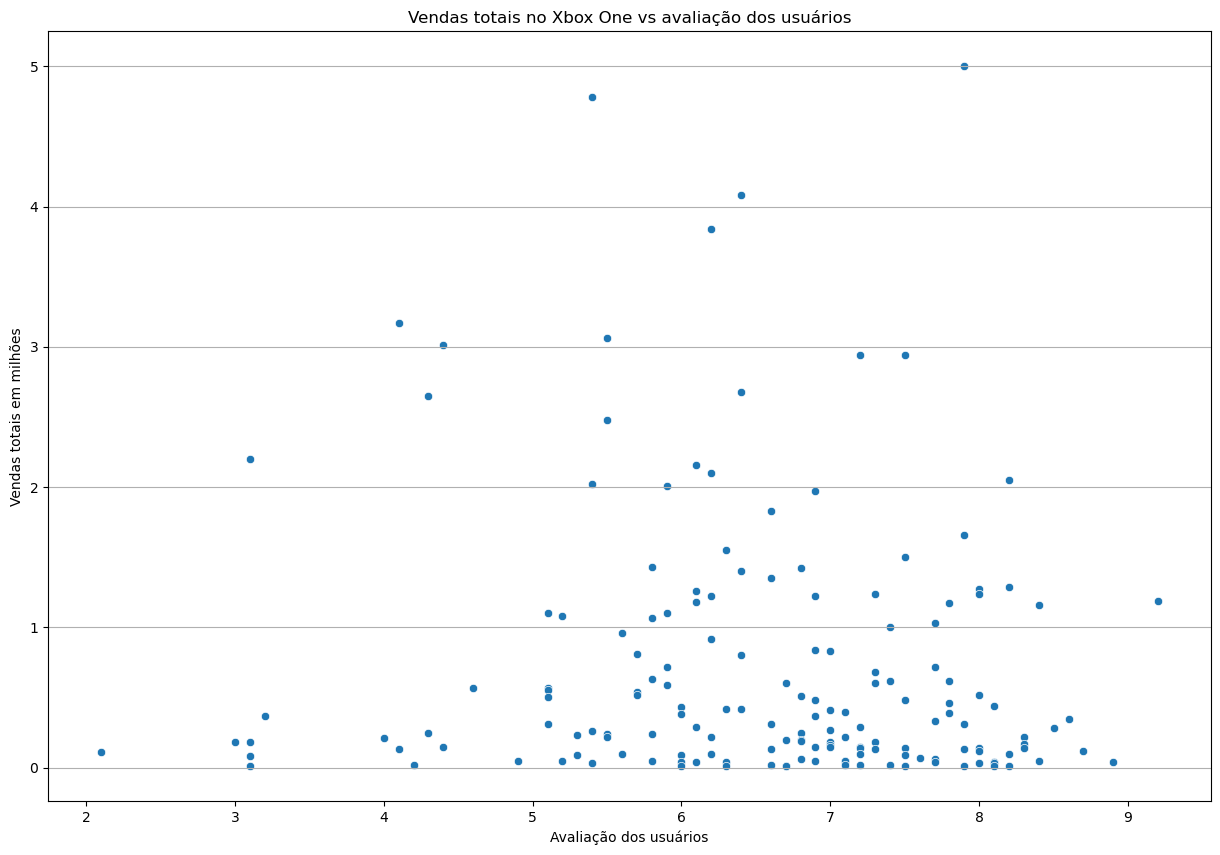

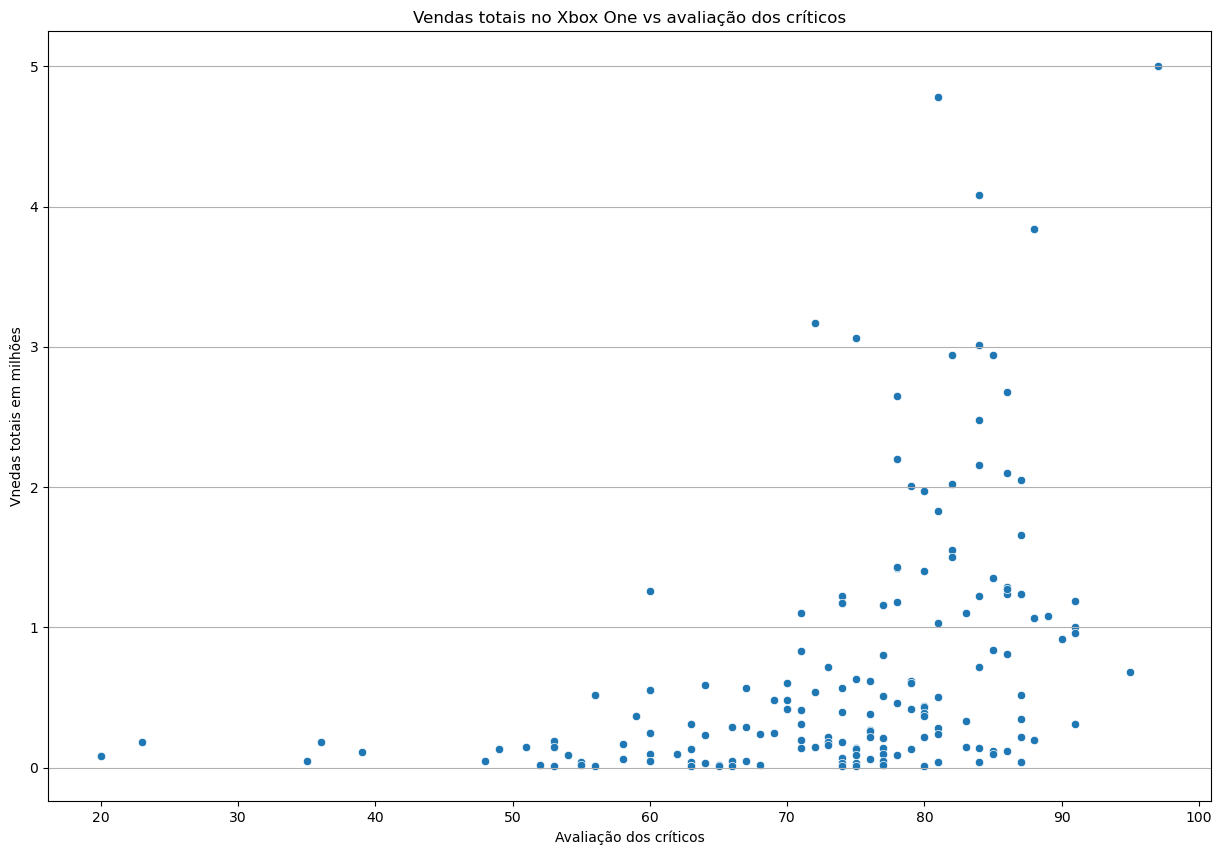

In [17]:
#Cria dois gráficos de dispersão que analisam a relação entre as vendas de um console 
#(no caso o Xbox One) e a nota de avaliação dos críticos e usuários respectivamente


#Cria um dataframe chamado 'df_xone' que filtra apenas jogos de Xbox One que possuem notas de usuário e da crítica preenchidas
df_xone = df_games_recent[(df_games_recent['platform'] == 'XOne') & (df_games_recent['user_score'].notna()) & (df_games_recent['critic_score'].notna())]

#Calcula a matriz de correlação
correlation_matrix = df_xone[['total_sales', 'user_score', 'critic_score']].corr()
print('Matriz de correlação para Xbox One: ')
print(correlation_matrix)

#Gráfico de avaliação de usuários vs vendas
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'user_score', y = 'total_sales', data = df_xone)
plt.title('Vendas totais no Xbox One vs avaliação dos usuários')
plt.xlabel('Avaliação dos usuários')
plt.ylabel('Vendas totais em milhões')
plt.grid(axis = 'y')
plt.show()

#Gráfico de avliação de críticos vs vendas
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'critic_score', y = 'total_sales', data = df_xone)
plt.title('Vendas totais no Xbox One vs avaliação dos críticos')
plt.xlabel('Avaliação dos críticos')
plt.ylabel('Vnedas totais em milhões')
plt.grid(axis = 'y')
plt.show()

**Ao se analizar o gráfico, percebe-se que os jogos que mais vendem no Xbox One são aqueles que possuem uma nota de usuário acima de 6 e uma nota de críticos acima de 7.**

**Ao analizar a matriz de correlação também pose-se concluir que, para o Xbox One, a avaliação dos críticos é um indicador muito mais forte do sucesso comercial de um jogo do que a avaliação dos usuários.**

**Para termos uma melhor ideia quanto a venda de jogos comparada as notas de usuários e críticos, a seguir será analizado a relação das vendas totais de jogos comparadas as notas de críticos e usuários a partir do Playstation 4, Playstation 3 e Nintendo Wii.**

Matriz de correlação para Playstation 4: 
              total_sales  user_score  critic_score
total_sales      1.000000   -0.032923      0.405223
user_score      -0.032923    1.000000      0.557654
critic_score     0.405223    0.557654      1.000000


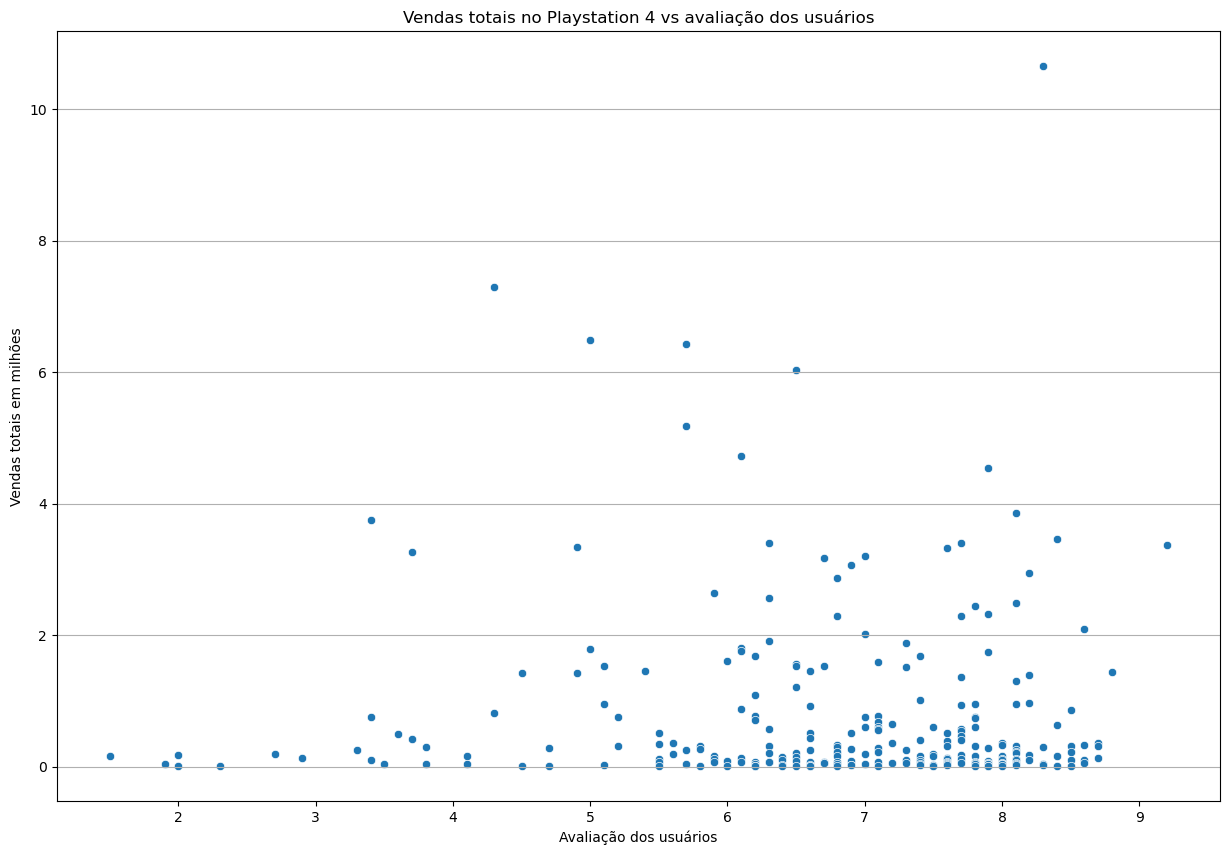

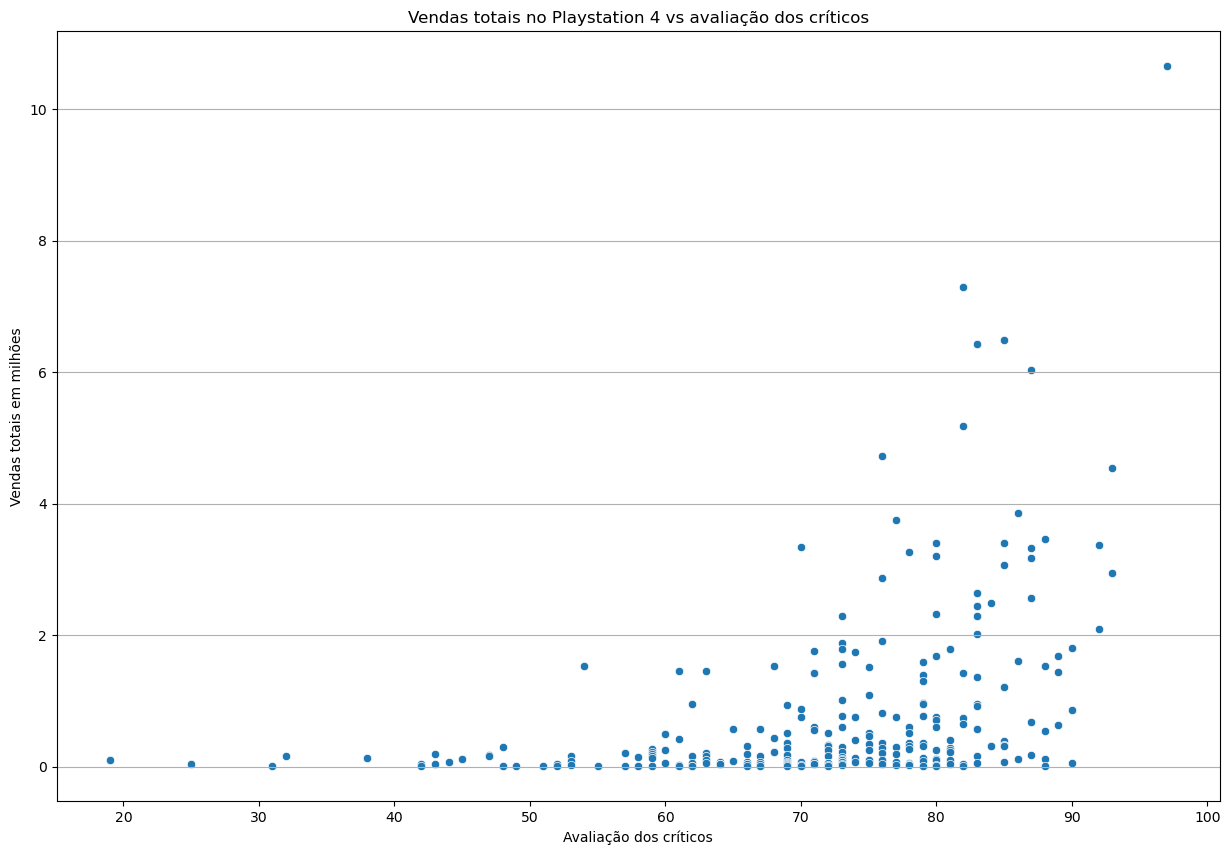

In [18]:
#Cria dois gráficos de dispersão que analisam a relação entre as vendas de outro console 
#(agora este sendo o Playstation 4) e a nota de avaliação dos críticos e usuários respectivamente

#Cria um dataframe chamado 'df_ps4' que filtra apenas jogos de xbox 360 que possuem notas de usuário e da crítica preenchidas
df_ps4 = df_games_recent[(df_games_recent['platform'] == 'PS4') & (df_games_recent['user_score'].notna()) & (df_games_recent['critic_score'].notna())]

#Calcula a matriz de correlação
correlation_matrix = df_ps4[['total_sales', 'user_score', 'critic_score']].corr()
print('Matriz de correlação para Playstation 4: ')
print(correlation_matrix)

#Gráfico de avaliação de usuários vs vendas
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'user_score', y = 'total_sales', data = df_ps4)
plt.title('Vendas totais no Playstation 4 vs avaliação dos usuários')
plt.xlabel('Avaliação dos usuários')
plt.ylabel('Vendas totais em milhões')
plt.grid(axis = 'y')
plt.show()

#Gráfico de avaliação de críticos vs vendas
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'critic_score', y = 'total_sales', data = df_ps4)
plt.title('Vendas totais no Playstation 4 vs avaliação dos críticos')
plt.xlabel('Avaliação dos críticos')
plt.ylabel('Vendas totais em milhões')
plt.grid(axis = 'y')
plt.show()

Matriz de correlação para Nintendo 3DS: 
              total_sales  user_score  critic_score
total_sales      1.000000    0.272542      0.337887
user_score       0.272542    1.000000      0.769536
critic_score     0.337887    0.769536      1.000000


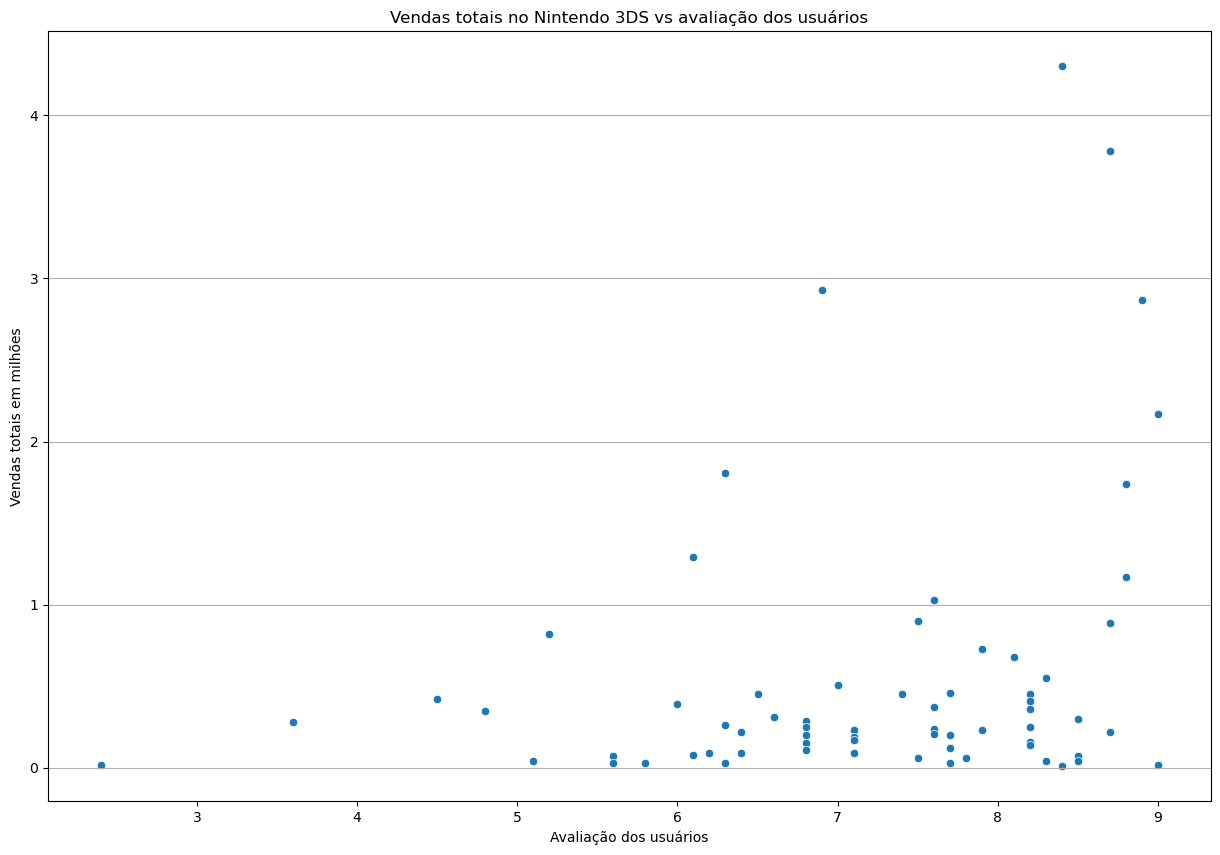

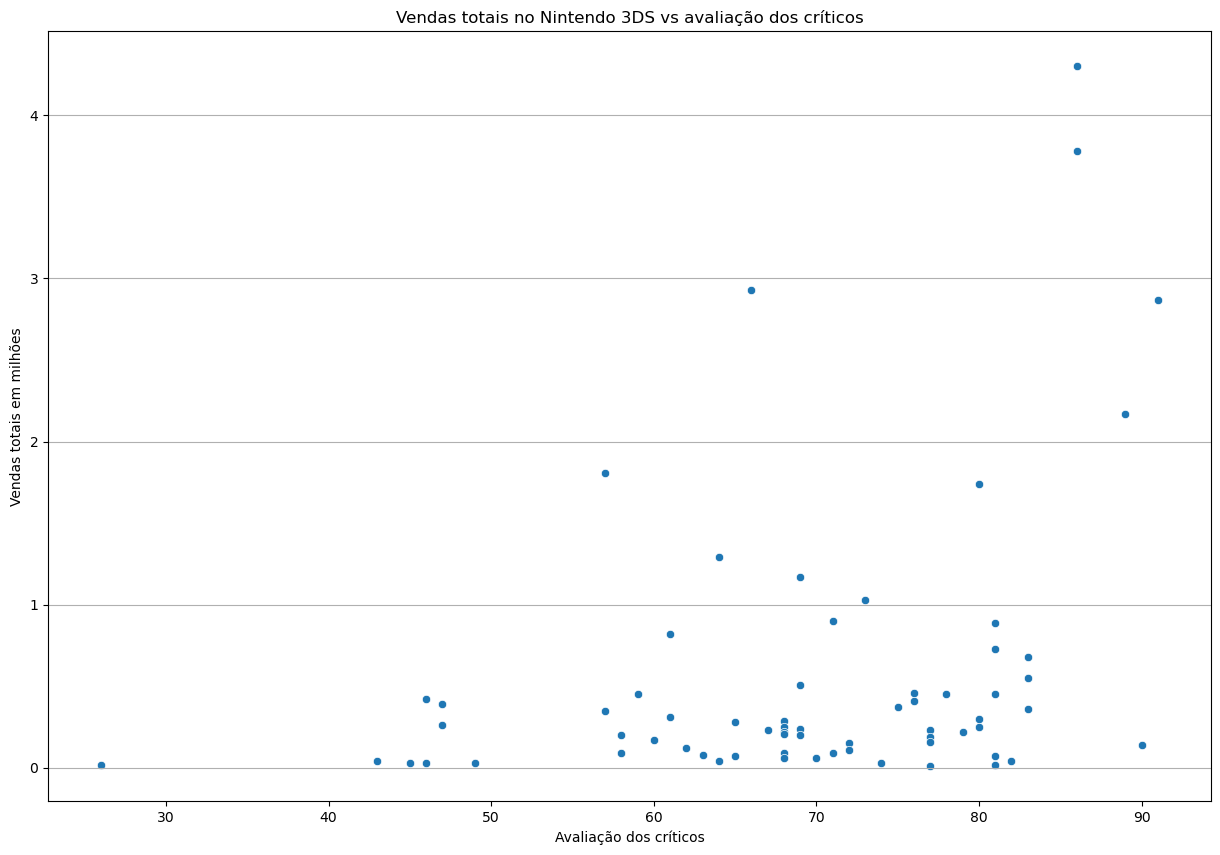

In [19]:
#Cria dois gráficos de dispersão que analisam a relação entre as vendas de outro console 
#(agora este sendo o Nintendo 3DS) e a nota de avaliação dos críticos e usuários respectivamente

#Cria um dataframe chamado 'df_3ds' que filtra apenas jogos de Nintendo 3DS que possuem notas de usuário e da crítica preenchidas
df_3ds = df_games_recent[(df_games_recent['platform'] == '3DS') & (df_games_recent['user_score'].notna()) & (df_games_recent['critic_score'].notna())]

#Calcula a matriz de correlação
correlation_matrix = df_3ds[['total_sales', 'user_score', 'critic_score']].corr()
print('Matriz de correlação para Nintendo 3DS: ')
print(correlation_matrix)

#Gráfico de avaliação de usuários vs vendas
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'user_score', y = 'total_sales', data = df_3ds)
plt.title('Vendas totais no Nintendo 3DS vs avaliação dos usuários')
plt.xlabel('Avaliação dos usuários')
plt.ylabel('Vendas totais em milhões')
plt.grid(axis = 'y')
plt.show()

#Gráfico de avaliação de críticos vs vendas
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'critic_score', y = 'total_sales', data = df_3ds)
plt.title('Vendas totais no Nintendo 3DS vs avaliação dos críticos')
plt.xlabel('Avaliação dos críticos')
plt.ylabel('Vendas totais em milhões')
plt.grid(axis = 'y')
plt.show()

Matriz de correlação para Nintendo WiiU: 
              total_sales  user_score  critic_score
total_sales      1.000000    0.407859      0.377701
user_score       0.407859    1.000000      0.721313
critic_score     0.377701    0.721313      1.000000


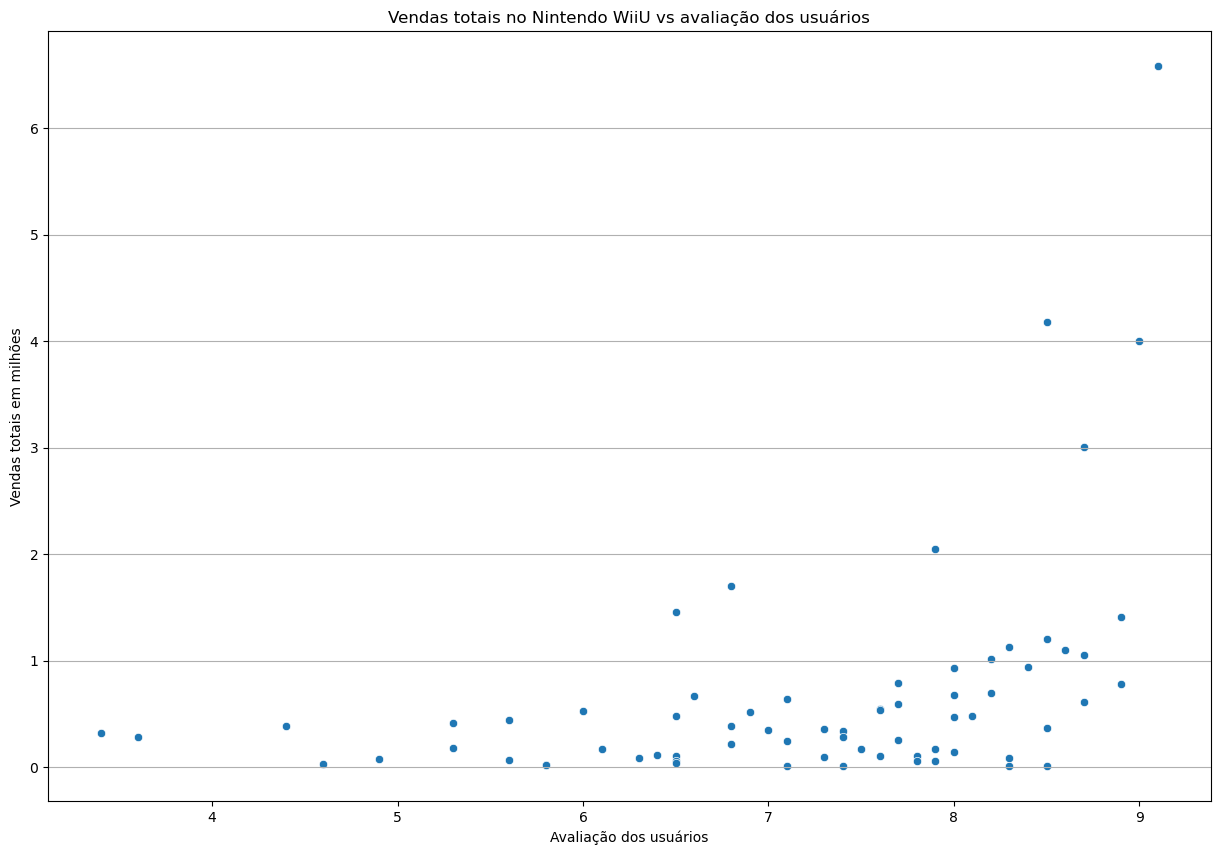

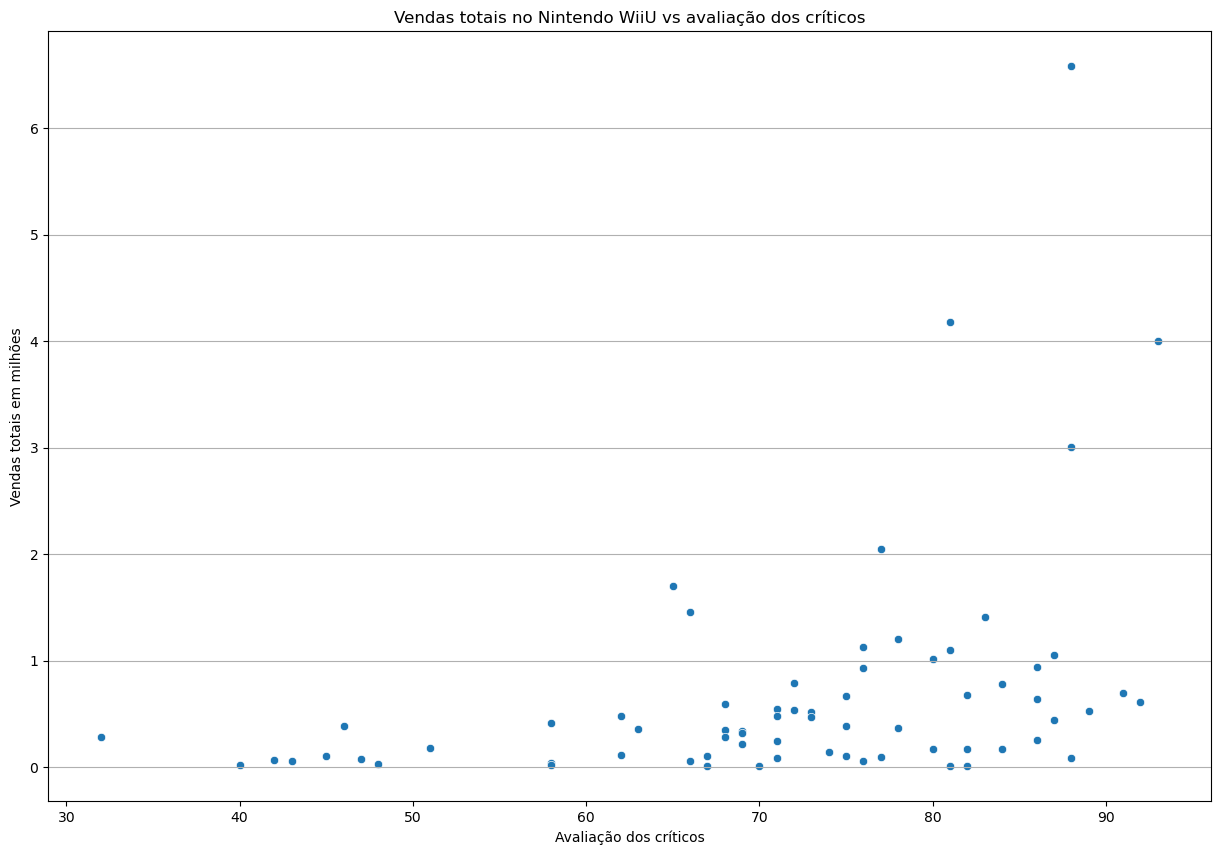

In [20]:
#Cria dois gráficos de dispersão que analisam a relação entre as vendas de outro console 
#(agora este sendo o Nintendo WiiU) e a nota de avaliação dos críticos e usuários respectivamente

#Cria um dataframe chamado 'df_wiiu' que filtra apenas jogos de WiiU que possuem notas de usuário e da crítica preenchidas
df_wiiu = df_games_recent[(df_games_recent['platform'] == 'WiiU') & (df_games_recent['user_score'].notna()) & (df_games_recent['critic_score'].notna())]

#Calcula a matriz de correlação
correlation_matrix = df_wiiu[['total_sales', 'user_score', 'critic_score']].corr()
print('Matriz de correlação para Nintendo WiiU: ')
print(correlation_matrix)

#Gráfico de avaliação de usuários vs vendas
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'user_score', y = 'total_sales', data = df_wiiu)
plt.title('Vendas totais no Nintendo WiiU vs avaliação dos usuários')
plt.xlabel('Avaliação dos usuários')
plt.ylabel('Vendas totais em milhões')
plt.grid(axis = 'y')
plt.show()

#Gráfico de avaliação de críticos vs vendas
plt.figure(figsize = (15, 10))
sns.scatterplot(x = 'critic_score', y = 'total_sales', data = df_wiiu)
plt.title('Vendas totais no Nintendo WiiU vs avaliação dos críticos')
plt.xlabel('Avaliação dos críticos')
plt.ylabel('Vendas totais em milhões')
plt.grid(axis = 'y')
plt.show()

**Analisando os gráficos pode-se concluir o seguinte:**

**Os jogos que mais vendem no Playstation 4 são aqueles que possuem uma nota de usuário de por volta de 5.5 para cima e uma nota de críticos acima de 7.**

**Os jogos que mais vendem no Nintendo 3DS são aqueles que possuem uma nota de usuário e de críticos de 6 para cima.**

**Os jogos que mais vendem no Nintendo WiiU são aqueles que possuem uma nota de usuário de 6.5 para cima e uma nota de críticos de 7.**

**Ao analizar a matrizes de correlação de cada um dos três consoles, conclui-se que, para o Playstation 4, a avaliação dos críticos é um indicador muito mais forte do sucesso comercial de um jogo do que a avaliação dos usuários, para o Nintendo 3DS e Nintendo WiiU, demonstra uma relação mais equilibrada, com a correlação das avaliações dos críticos não sendo muito diferentes das avaliações de usuários nesses consoles.**

**Pode-se concluir que a maioria dos consumidores terá uma chance maior de comprar um jogo se ele tiver uma nota por volta de 6 vinda dos usuários ou uma nota por volta de 7 vinda da crítica.**

Número de jogos por gênero
genre
Action          766
Role-Playing    292
Adventure       245
Sports          214
Shooter         187
Misc            155
Racing           85
Fighting         80
Platform         74
Simulation       62
Strategy         56
Puzzle           17
Name: count, dtype: int64

Vendas de jogos por gênero (Em milhões/bilhões)
genre
Action          284.67
Shooter         204.21
Role-Playing    134.41
Sports          131.20
Misc             56.73
Platform         38.51
Racing           35.45
Fighting         31.75
Adventure        21.21
Simulation       20.30
Strategy          9.27
Puzzle            3.01
Name: total_sales, dtype: float64


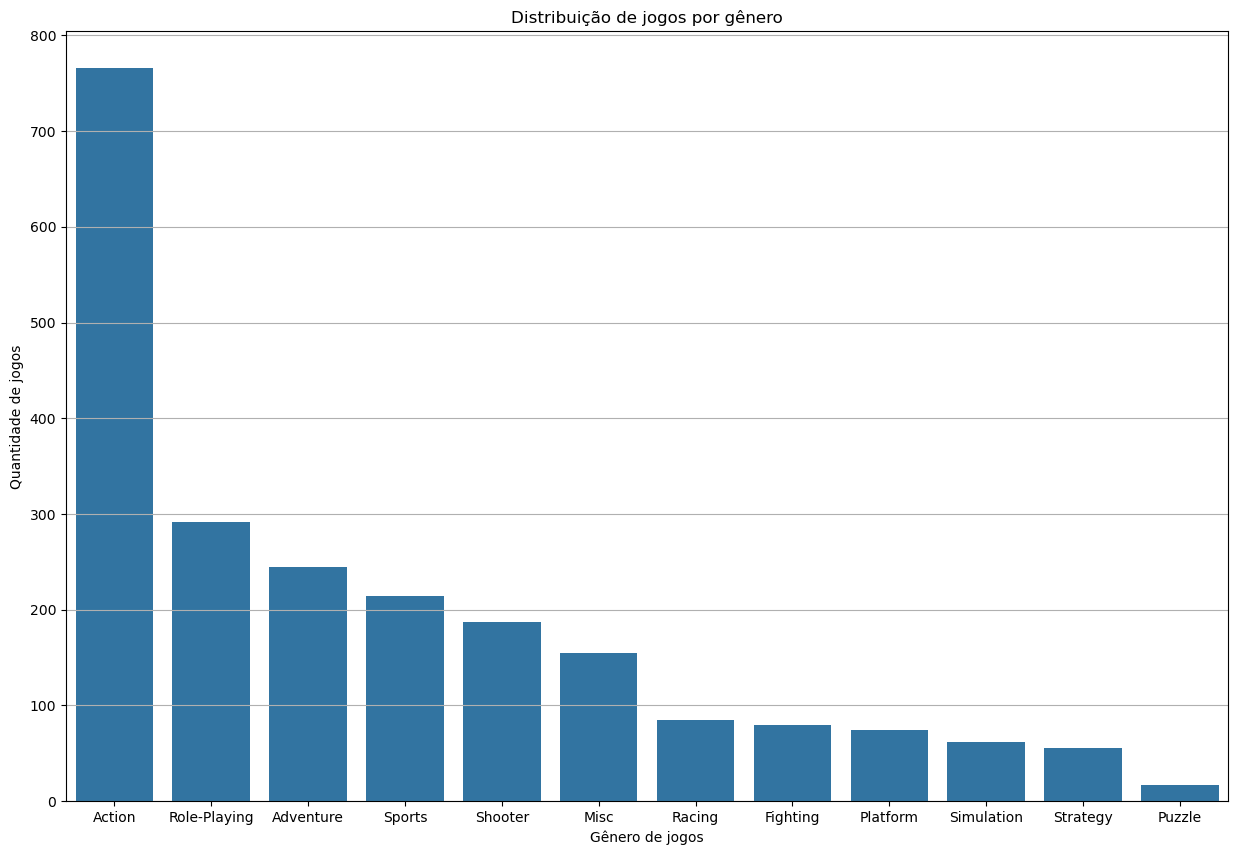

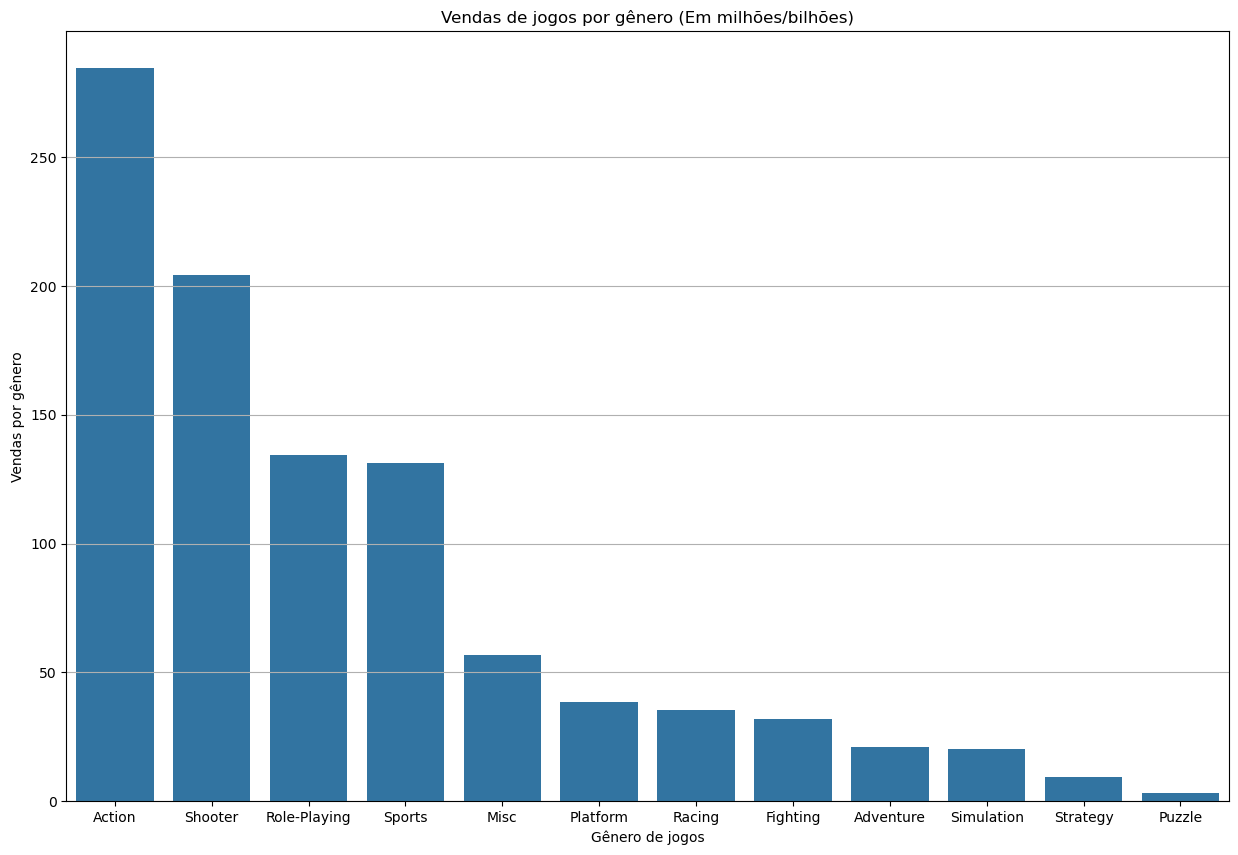

In [21]:
#Agora será contado a distribuição de jogos em cada gênero e suas vendas dentro dos valores filtrados
games_by_genre_count = df_games_recent['genre'].value_counts()
games_by_genre_sales = df_games_recent.groupby('genre')['total_sales'].sum().sort_values(ascending = False)

print('Número de jogos por gênero')
print(games_by_genre_count)
print()
print('Vendas de jogos por gênero (Em milhões/bilhões)')
print(games_by_genre_sales)

#Gera dois gráficos de barras para melhor observação dos números

plt.figure(figsize = (15, 10))
sns.barplot(x = games_by_genre_count.index, y = games_by_genre_count.values)
plt.title('Distribuição de jogos por gênero')
plt.xlabel('Gênero de jogos')
plt.ylabel('Quantidade de jogos')
plt.grid(axis = 'y')
plt.show()

plt.figure(figsize = (15, 10))
sns.barplot(x = games_by_genre_sales.index, y = games_by_genre_sales.values)
plt.title('Vendas de jogos por gênero (Em milhões/bilhões)')
plt.xlabel('Gênero de jogos')
plt.ylabel('Vendas por gênero')
plt.grid(axis = 'y')
plt.show()

**Analisando as informações e os gráficos pode-se tirar as seguintes conclusões:**

**O gênero "Action" domina tanto em termos de volume de jogos quanto em total de vendas. Jogos dos gêneros "Shooter", "Role-Playing" e "Sports" também são extremamente lucrativos, mesmo tendo um número menor de títulos do que Ação. Isso sugere que a receita por jogo nesses gêneros pode ser muito alta.**

**Falando de forma generalizada, generos com maior número de títulos (como Ação e Role-playing) sugerem uma indústria que aposta em grande volume de lançamentos nesses tipo de jogos. Gêneros como "Shooter" e "Sports", apesar de não ter o maior número de títulos, tem uma alta receita total, indicando que seus jogos de maior sucesso geram vendas massivas.**

**Quanto a gêneros como "Puzzle" e "Strategy", que tendem a ter um total de vendas e um número de títulos significativamente menores, esses dados indicam que eles são gêneros mais nichados, consequentemente, com um público mais limitado. A falta de grandes sucessos de vendas nesse gênero também é um fator.**

**Em geral, os generos mais lucrativos tendem a ser aqueles que produzem novos títulos constantemente ou que contam com grandes sucessos que vendem milhões de cópias por conta própria.**

# ETAPA 4: Criação de perfil de usuário por região.

**Para começar, será criado três gráficos de barra para determinar as 5 maiores plataformas nas três regiões (AN, UE, JP).**

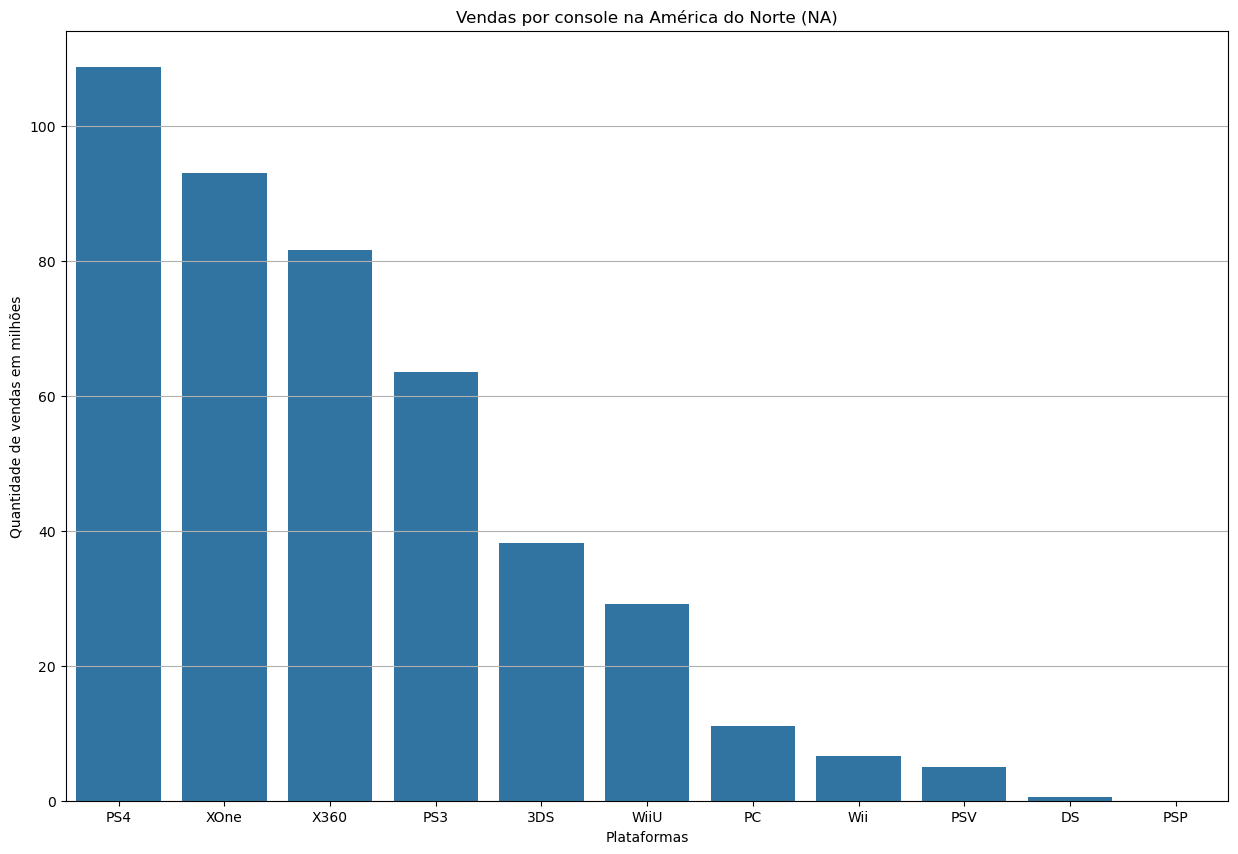

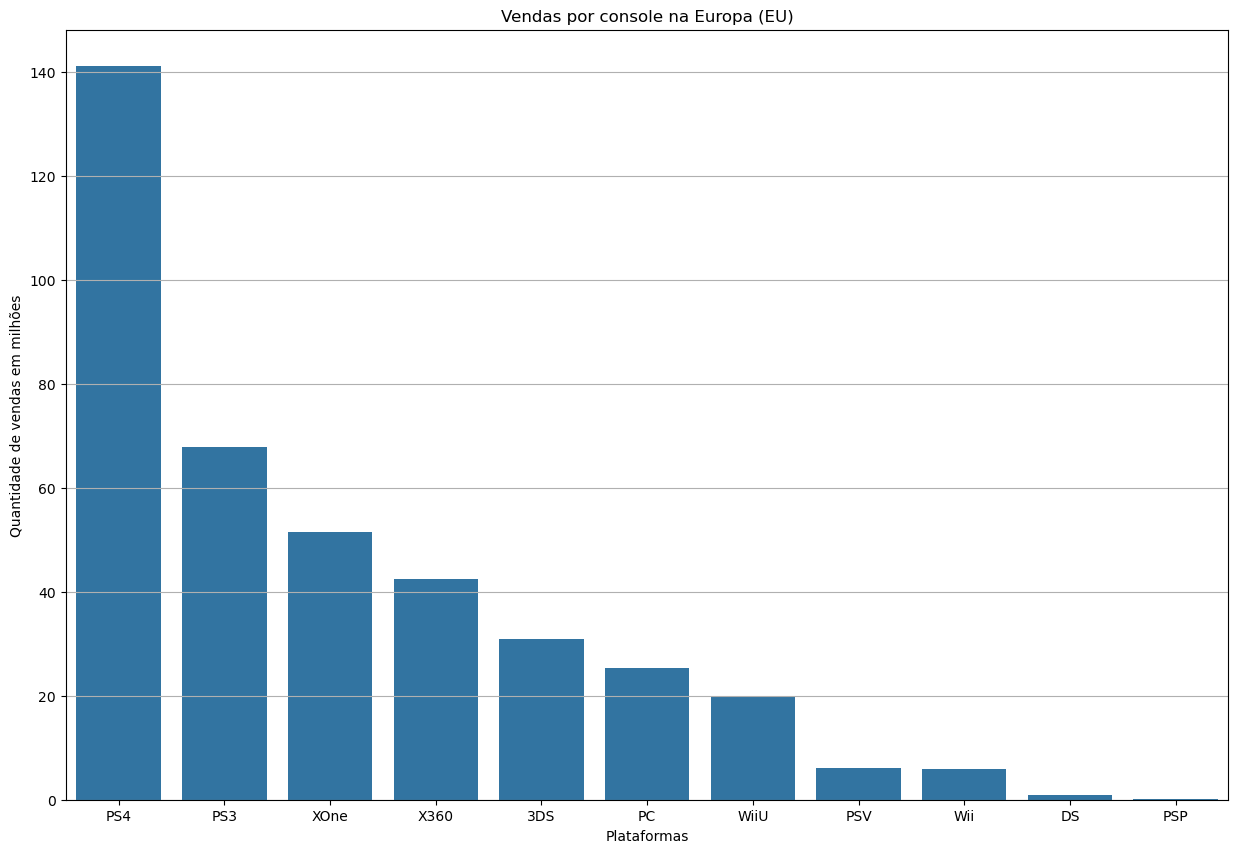

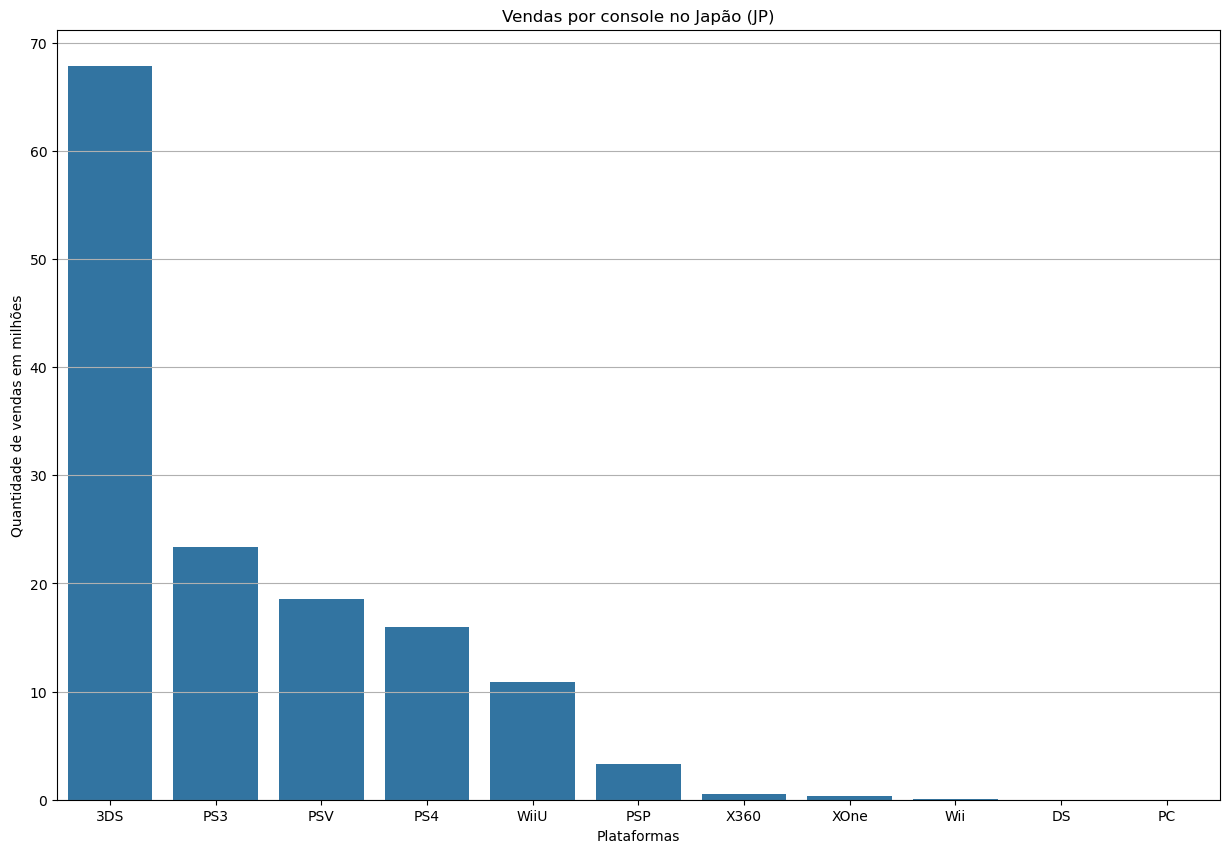

In [22]:
#Cria 3 dataframes feitos para filtar apenas os jogos por plataformas e regiões

df_platforms_NA = df_games_recent.groupby('platform')['na_sales'].sum().sort_values(ascending = False)
df_platforms_NA = df_platforms_NA.reset_index()

df_platforms_EU = df_games_recent.groupby('platform')['eu_sales'].sum().sort_values(ascending = False)
df_platforms_EU = df_platforms_EU.reset_index()

df_platforms_JP = df_games_recent.groupby('platform')['jp_sales'].sum().sort_values(ascending = False)
df_platforms_JP = df_platforms_JP.reset_index()

plt.figure(figsize = (15, 10))
sns.barplot(x = 'platform', y = 'na_sales', data = df_platforms_NA)
plt.title('Vendas por console na América do Norte (NA)')
plt.xlabel('Plataformas')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

plt.figure(figsize = (15, 10))
sns.barplot(x = 'platform', y = 'eu_sales', data = df_platforms_EU)
plt.title('Vendas por console na Europa (EU)')
plt.xlabel('Plataformas')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

plt.figure(figsize = (15, 10))
sns.barplot(x = 'platform', y = 'jp_sales', data = df_platforms_JP)
plt.title('Vendas por console no Japão (JP)')
plt.xlabel('Plataformas')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

**Analisando os gráficos, podemos determinar o seguinte sobre cada região a partir das 5 plataformas com mais vendas.**

***Top 5 América do Norte (NA): Playstation 4, Xbox One, Xbox 360, Playstation 3 e Nintendo 3DS.*** 

**O público da América do Norte em sua maioria consomem mais jogos das três grandes empresas de jogos (Microsoft, Sony e Nintendo). O Playstation 4 ser o mais popular entre os top 5 indica uma forte presença da Sony no mercado da região, com o Xbox One e 360 logo atrás, o que também indica uma forte presença da Microsoft também, justamente por esta ser uma empresa americana, o que ajuda na facilidade de aquisição de seus consoles. Por fim, o 3DS é o quinto console com mais vendas de jogos de 2013 para cá, o que mostra que uma parte considerável do público norte-americano está interessado em jogar em consoles portáteis.**

***Top 5 Europa (EU): Playstation 4, Playstation 3, Xbox One, Xbox 360, o Nintendo 3DS.*** 

**O público Europeu apesar de compartilhar muitas das mesmas preferencias de plataformas que a América do Norte, no entanto, as plataformas da Sony (Playstation 4 e 3) tem uma liderança mais pronunciada em vendas se comparado as plataformas da Microsoft, com o PS4 superando as vendas do Xbox One em torno de 90 milhões, mostrando uma presença muito maior da Sony na região.**

***Top 5 Japão (JP): Nintendo 3DS, Playstation 3, Playstation Vita, Playstation 4 e Nintendo WiiU.*** 

**O Público do Japão é o que possui as preferências mais distintas, primeiro que as 5 maiores plataformas são todas da Sony e da Nintendo, o que faz sentido, pois essas são duas marcas japonesas, o que deve facilitar para se estabelecer no mercado local, e segundo que desses 5 consoles, 2 deles são portáteis (3DS e PSV), o que indica que o público japonês tem uma maior preferência por consoles que lhes permitem jogar em diferentes lugares. Observando o gráfico como um todo, também percebe-se que as plataformas da Microsoft (Xbox 360 e Xbox One) não passam de 5 milhões de vendas, indicando uma fraquíssima presença no mercado da região.**

**Agora será analizados dos cinco maiores gêneros vendidos nas três regiões.**

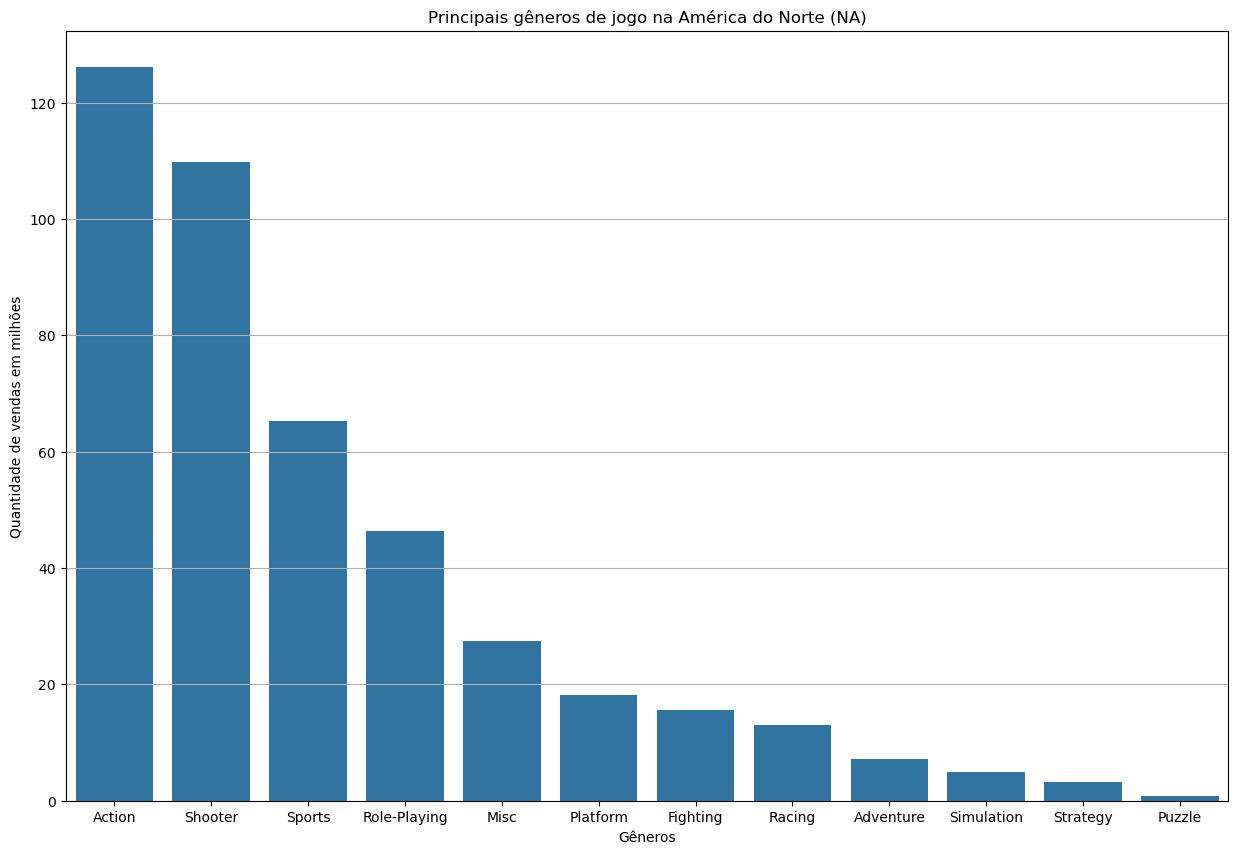

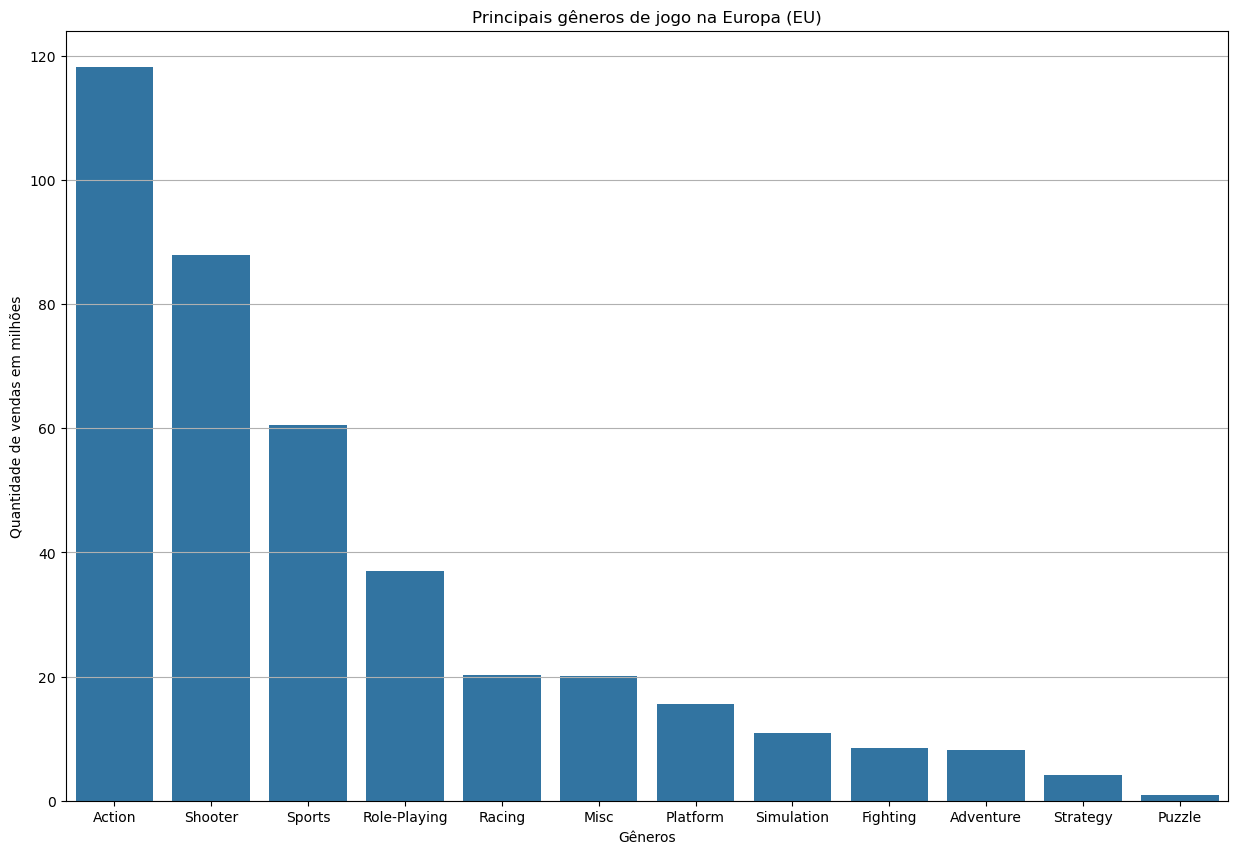

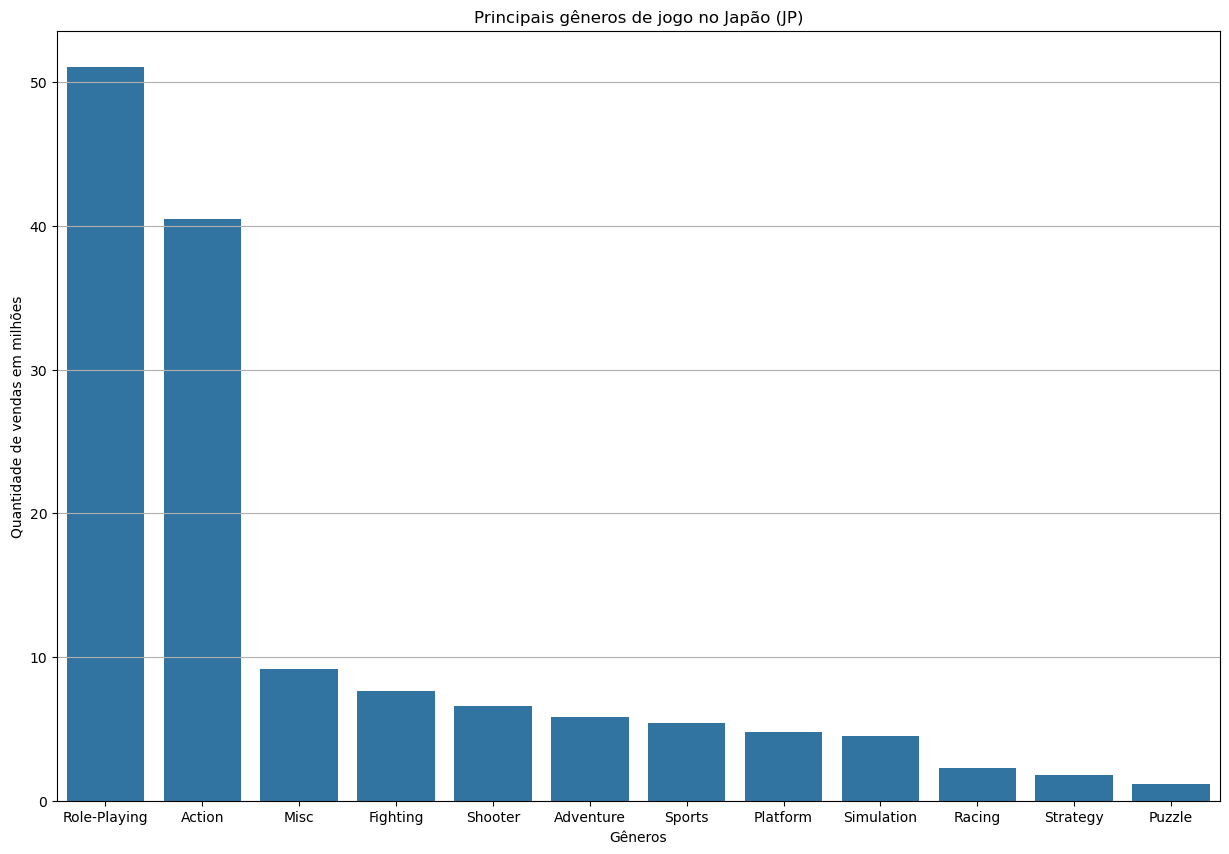

In [23]:
#Cria 3 dataframes feitos para filtar apenas os jogos por gêneros de jogo e regiões

df_genres_NA = df_games_recent.groupby('genre')['na_sales'].sum().sort_values(ascending = False)
df_genres_NA = df_genres_NA.reset_index()

df_genres_EU = df_games_recent.groupby('genre')['eu_sales'].sum().sort_values(ascending = False)
df_genres_EU = df_genres_EU.reset_index()

df_genres_JP = df_games_recent.groupby('genre')['jp_sales'].sum().sort_values(ascending = False)
df_genres_JP = df_genres_JP.reset_index()

plt.figure(figsize = (15, 10))
sns.barplot(x = 'genre', y = 'na_sales', data = df_genres_NA)
plt.title('Principais gêneros de jogo na América do Norte (NA)')
plt.xlabel('Gêneros')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

plt.figure(figsize = (15, 10))
sns.barplot(x = 'genre', y = 'eu_sales', data = df_genres_EU)
plt.title('Principais gêneros de jogo na Europa (EU)')
plt.xlabel('Gêneros')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

plt.figure(figsize = (15, 10))
sns.barplot(x = 'genre', y = 'jp_sales', data = df_genres_JP)
plt.title('Principais gêneros de jogo no Japão (JP)')
plt.xlabel('Gêneros')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

**Analisando os gráficos, podemos determinar o seguinte sobre cada região a partir dos 5 gêneros com mais vendas.**

***Top 5 América do Norte (NA): Action, Shooter, Sports, Role-Playing e Misc.*** 

**O público da América do Norte em sua maioria consomem mais jogos dos gêneros de ação, tiro e esporte, mostrando uma forte garantia de lucros para se investir nesses gêneros na região, além desses, jogos de gêneros RPG e miscelâneos também são bem populares entre os consumidores norte-americanos.**

***Top 5 Europa (EU): Action, Shooter, Sports, Role-Playing e Racing.*** 

**O público Europeu compartilha essencialmente as mesmas preferencias de gêneros que a América do Norte, com a única diferença sendo que jogos de corrida tem uma presença bem mais forte no mercado de lá se comparado ao mercado norte-americano.**

***Top 5 Japão (JP): Role-Playing, Action, Misc, Fighting, Shooter.*** 

**O Público do Japão é novamente o que possui as preferências mais distintas, tendo os jogos de RPG como os mais populares na região. O gênero Role-Playing é de longe o mais popular, seguido por jogos de ação, miscelâneos e de luta (gênero esse que está entre os menos populares nas outras regiões). O gêneros de corrida e de tiro, que são extremamente populares na América do Norte e Europa, apesar de estar entre os 5 generos mais vendidos, é o menos popular deles, vendendo menos de 10 milhões, indicando que o mercado japonês possui um nicho mais distinto se comparado ás outras regiões ocidentais.**

**Agora serão analizadas as maiores classificações indicativas vendidas nas três regiões.**

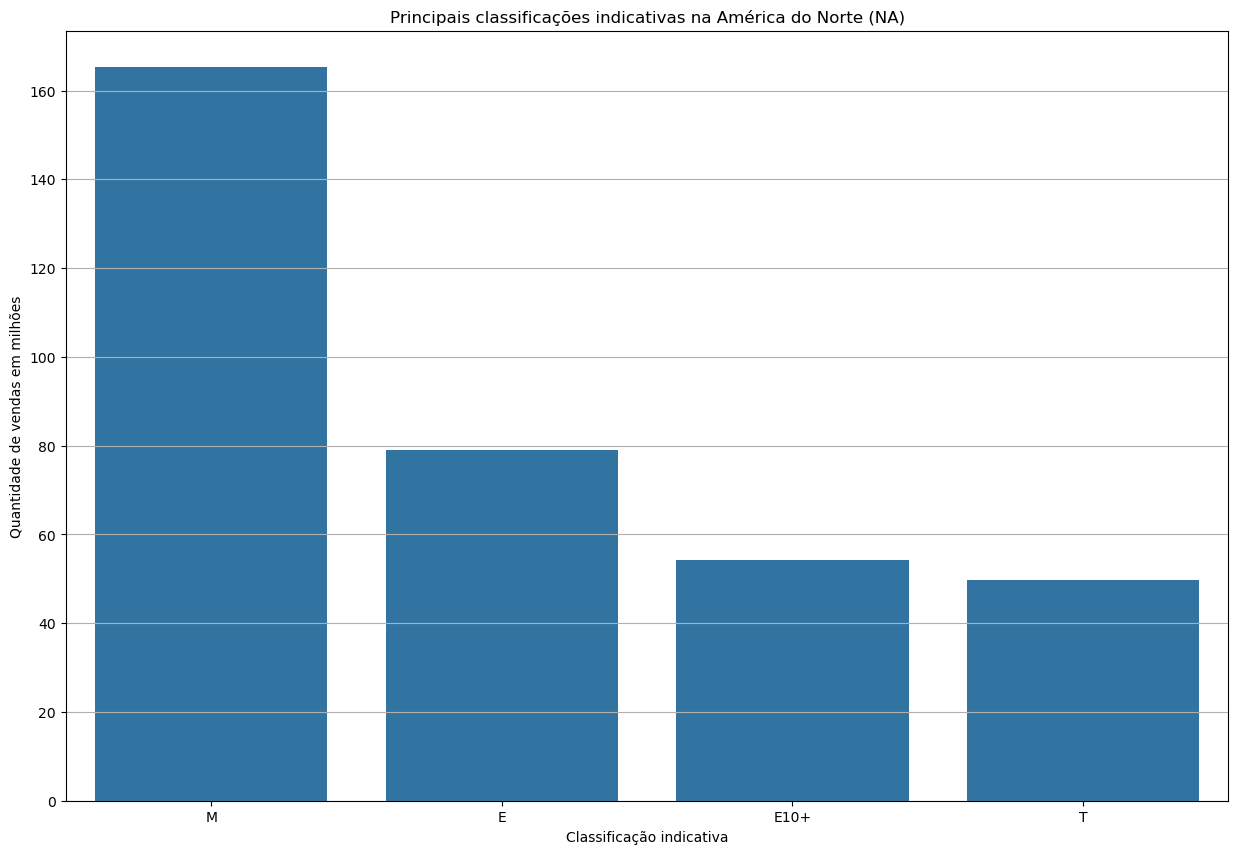

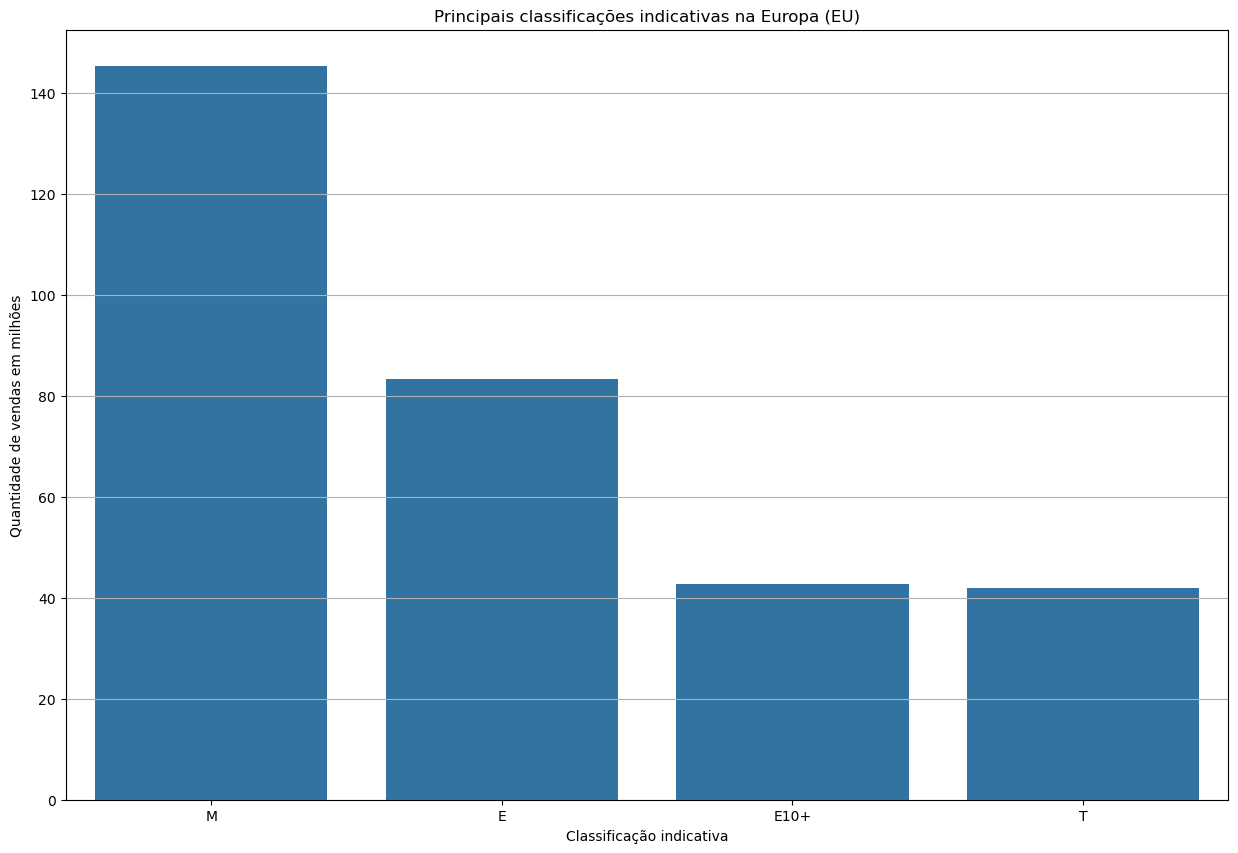

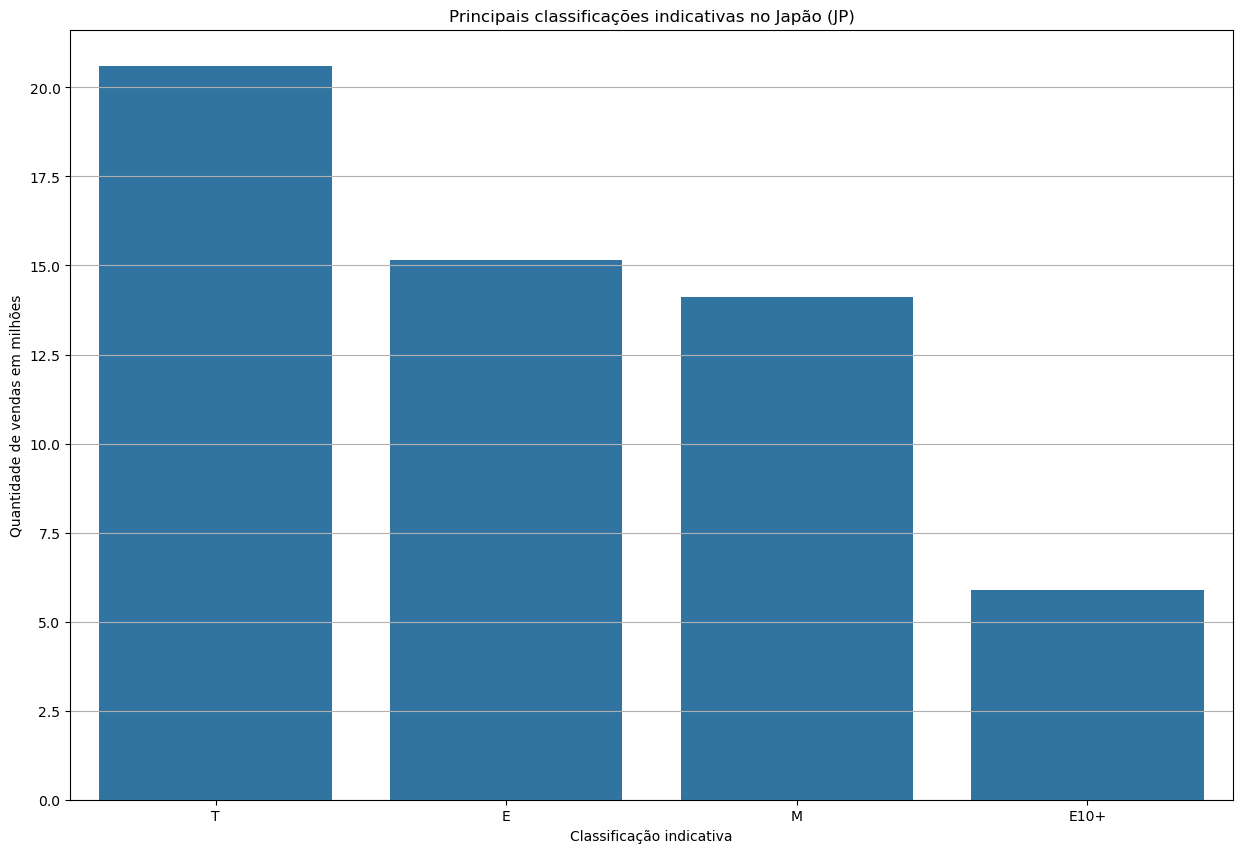

In [24]:
#Cria 3 dataframes feitos para filtar apenas os jogos por classificações indicativas e regiões

df_rating_NA = df_games_recent.groupby('rating')['na_sales'].sum().sort_values(ascending = False)
df_rating_NA = df_rating_NA.reset_index()

df_rating_EU = df_games_recent.groupby('rating')['eu_sales'].sum().sort_values(ascending = False)
df_rating_EU = df_rating_EU.reset_index()

df_rating_JP = df_games_recent.groupby('rating')['jp_sales'].sum().sort_values(ascending = False)
df_rating_JP = df_rating_JP.reset_index()

plt.figure(figsize = (15, 10))
sns.barplot(x = 'rating', y = 'na_sales', data = df_rating_NA)
plt.title('Principais classificações indicativas na América do Norte (NA)')
plt.xlabel('Classificação indicativa')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

plt.figure(figsize = (15, 10))
sns.barplot(x = 'rating', y = 'eu_sales', data = df_rating_EU)
plt.title('Principais classificações indicativas na Europa (EU)')
plt.xlabel('Classificação indicativa')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

plt.figure(figsize = (15, 10))
sns.barplot(x = 'rating', y = 'jp_sales', data = df_rating_JP)
plt.title('Principais classificações indicativas no Japão (JP)')
plt.xlabel('Classificação indicativa')
plt.ylabel('Quantidade de vendas em milhões')
plt.grid(axis = 'y')

**Analisando os gráficos, podemos determinar o seguinte sobre cada região a partir das 5 classificações indicativas com mais vendas.**

***América do Norte (NA): M (Mature), E (Everyone), E10+ (Everyone 10+) e T (Teens).*** 

**Na América do Norte As vendas são dominadas por jogos classificados como M (Mature), seguidos de perto pelos jogos E (Everyone) e E10+ (Everyone 10+). Isso deve ser reflexo da popularidade de jogos do gênero de ação, tiro e RPG, em que muitos jogos desses gêneros são feitos para públicos mais maduros. Jogos E e E10+ devem refletir a popularidade do gênero de esportes, que em no geral é gênero mais acessível a um público mais novo.**

***Europa (EU): M (Mature), E (Everyone), E10+ (Everyone 10+) e T (Teens).*** 

**O padrão de vendas na Europa é idêntico ao da América do Norte, com a classificação M liderando as vendas, seguida por E, E10+ e T. As preferências de jogos por classificação indicativa nos dois mercados ocidentais são, portanto, iguais.**

***Japão (JP): T (Teens), E (Everyone), M (Mature) e E10+ (Everyone 10+).*** 

**E mais uma vez o Público japonês é o que possui um mercado mais único, as vendas de jogos M não dominam o mercado japonês, mas sim jogos de classificação T, que são os menos populares no ocidente. Isso deve ser reflexo da popularidade dos jogos da Nintendo na região, que tendem a não passar da classificação T.**

# ETAPA 5. Teste de hipóteses.

**HIPÓTESE 1:**

**As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.**

**HIPÓTESE NULA: As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.**

**HIPÓTESE ALTERNATIVA: As classificações médias dos usuários das plataformas Xbox One e PC são diferentes.**

**O nível de significância (alpha) escolhido é 0.05, ou seja, estamos dispostos a aceitar uma chance de 5% de erro Tipo I, ou seja, uma chance de 5% de rejeitar a hipótese nula quando ela é, na verdade, verdadeira.**

In [25]:
#TESTE DA HIPÓTESE

#1. Filtrar os dados das classificações médias de usuários para Xbox One e PC
xbox_one_user_score = df_games_recent[(df_games_recent['platform'] == 'XOne')]['user_score'].dropna()
pc_user_score = df_games_recent[(df_games_recent['platform'] == 'PC')]['user_score'].dropna()

#2. Determinar alpha
alpha = 0.05

#3. Verificar se há igualdade de variâncias usando o teste de Levene
levene_test_stat, levene_p_value = st.levene(xbox_one_user_score, pc_user_score)

print(f'A variância das classificações de usuários de Xbox One é: {xbox_one_user_score.var():.4f}')
print(f'A variância das avaliações de usuários de PC é: {pc_user_score.var():.4f}')
print(f'O valor-p do Teste de Levene para igualdade de variâncias é: {levene_p_value:.4f}')

equal_variances = False
if levene_p_value > alpha:
    equal_variances = True
    print('Assumimos variâncias iguais para o teste t (p-valor de Levene > alpha)')
else:
    print('Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)')

#Como estamos comparando as análises vindas de duas plataformas diferentes sem nenhuma relação, faremos um teste t independente
#4. Realizar um teste t independente para testar as hipóteses
results = st.ttest_ind(xbox_one_user_score, pc_user_score, equal_var = equal_variances)

print('Valor-p:', results.pvalue)
if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula')
    print('Existe uma diferença estatística significante entre as classificações médias de usuários do Xbox One e PC.')
else:
    print('Não podemos rejeitar a hipótese nula')
    print('As médias de notas de usuários do Xbox One e PC são muito próximas.')

A variância das classificações de usuários de Xbox One é: 1.9070
A variância das avaliações de usuários de PC é: 3.0359
O valor-p do Teste de Levene para igualdade de variâncias é: 0.0039
Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)
Valor-p: 0.14759594013430463
Não podemos rejeitar a hipótese nula
As médias de notas de usuários do Xbox One e PC são muito próximas.


**HIPÓTESE 2:**

**As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.**

**HIPÓTESE NULA: As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.**

**HIPÓTESE ALTERNATIVA: As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são as mesmas.**

**O nível de significância (alpha) escolhido é 0.05, ou seja, estamos dispostos a aceitar uma chance de 5% de erro Tipo I, ou seja, uma chance de 5% de rejeitar a hipótese nula quando ela é, na verdade, verdadeira.**

In [28]:
#TESTE DA HIPÓTESE

#1. Filtrar os dados das classificações médias de usuários para action e sports
df_action_user_score = df_games_recent[(df_games_recent['genre'] == 'Action')]['user_score'].dropna()
df_sports_user_score = df_games_recent[(df_games_recent['genre'] == 'Sports')]['user_score'].dropna()

#2. Determinar alpha
alpha = 0.05

#3. Verificar se há igualdade de variâncias usando o teste de Levene
levene_test_stat, levene_p_value = st.levene(df_action_user_score, df_sports_user_score)

print(f'A variança das classificações de usuários do gênero action é: {df_action_user_score.var():.4f}')
print(f'A variança das classificações de usuários do gênero sports é: {df_action_user_score.var():.4f}')
print(f'O valor-p do Teste de Levene para igualdade de variâncias é: {levene_p_value:.4f}')

equal_variances = False
if levene_p_value > alpha:
    equal_variances = True
    print('Assumimos variâncias iguais para o teste t (p-valor de Levene > alpha)')
else:
    print('Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)')

#Como estamos comparando as análises vindas de dois gêneros diferentes sem nenhuma relação, faremos um teste t independente
#4. Realizar um teste t independente para testar as hipóteses
results = st.ttest_ind(df_action_user_score, df_sports_user_score, equal_var = equal_variances)

print('Valor P:', results.pvalue)
if results.pvalue < alpha:
    print('Não podemos rejeitar a hipótese nula')
    print('Existe uma clara semelhança nas classificações médias de usuários entre os jogos de gênero esporte e ação.')
else:
    print('Rejeitamos a hipótese nula')
    print('Há uma diferença distinta entre a média de classificação de usuários entre os jogos de gênero esporte e ação.')

A variança das classificações de usuários do gênero action é: 1.7694
A variança das classificações de usuários do gênero sports é: 1.7694
O valor-p do Teste de Levene para igualdade de variâncias é: 0.0000
Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)
Valor P: 1.4460039700704315e-20
Não podemos rejeitar a hipótese nula
Existe uma clara semelhança nas classificações médias de usuários entre os jogos de gênero esporte e ação.


# ETAPA 6: Conclusão.

**Considerando todos os dados analizados, podemos chegar a estas conclusões:**

**1. O mercado de videogames é dividido em pelo menos dois perfis de público distintos, com preferências de plataforma, gênero e classificação indicativa diferentes. A principal divisão é entre os mercados ocidentais (América do Norte e Europa) e o mercado japonês, então, os fatores das preferencias regionais deverá ser essencial no marketing da Ice para garantirem que eles possuam um forte ano de vendas em 2017.**

**2. O tempo de vida de uma geração de consoles é por volta de 5 a 7 anos, como estamos entrando em 2017 e o Xbox One, PS4 e WiiU (geração atual) foram lançados no período de 2012 a 2013, há uma chance baixa de um novo console grande surgir no mercado. De acordo com as nossas análises, um console após o lançamento costuma crescer em vendas por volta de 2 a 4 anos, ou seja, O novos consoles (especialmente o Xbox One e o PS4) ainda tem potêncial para muitas vendas, com a excessão sendo o WiiU, que já apresenta uma decadência em vendas.**

**3. Em 2016, a sétima geração de consoles (360, PS3 e Wii) estão decaindo mais e mais devido aos novos consoles estarem cada vez mais tomando lugar no mercado, logo, o ideal seria não investir muito nos jogos dessas plataformas e dar um foco maior para os consoles que estão em ascensão, sendo esses o Xbox One, o Playstation 4 e, surpreendentemente, o Nintendo 3DS, que apesar de sua idade, ainda apresenta uma boa quantidade de jogos lançados em 2016.**

**4. Quanto as notas tanto de usuários quanto as notas de críticos, percebe-se que os jogos que vendem mais geralmente possuem uma nota de usuário de 6 pra cima e uma nota da crítica de 7 pra cima, então, seria ideal a Ice investir e promover jogos que possuam essas notas.**

**5. Ao analizar os perfis dos usuários nas três regiões, percebe-se que seria de interesse da Ice promover diferentes jogos e consoles para cada região com base nas seguintes perfis de usuário:**

**Os usuários da América do Norte preferem principalmente jogos dos Gêneros de ação, tiro e esporte, geralemente de classificações indicativas de M, E, e E10+ e jogam mais nos consoles da Sony e da Microsoft.**

**Os usuários da Europa tem um gosto similar aos norte-americanos tanto nos gêneros quanto nas classificações indicativas, a diferença seria que eles possuem uma preferência maior aos consoles da Sony.**

**O japão é entre eles a região mais diferente, com usuários preferindo jogos do gênero de RPG, ação e luta, sendo esses jogos mais para as classificações T e E, além de terem preferência aos consoles da Nintendo e da Sony.**

**6. Em resumo, Para a Ice ter um bom ano de vendas em 2017, é ideal que eles sigam a seguinte estratégia de marketing:**

**Para os mercados Ocidentais: Focar em plataformas populares como PlayStation e Xbox. Promover e comercializar jogos dos gêneros de ação, tiro e esportes, com classificações indicativas M, E e E10+.**

**Para o Mercado Japonês: Focar nas plataformas da Nintendo e da Sony. Priorizar os jogos de RPG, ação e luta, com classificações indicativas T e E.**